### Import Libraries

In [26]:
# ── Imports ──────────────────────────────────────────────────────────────────
import os, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import plotly.graph_objects as go
import plotly.express as px
from itertools import cycle
import tensorflow as tf
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import (mean_absolute_error, mean_squared_error, r2_score)
from sklearn import metrics

warnings.filterwarnings('ignore')
%matplotlib inline
print("TF version:", tf.__version__)

TF version: 2.20.0


In [27]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, Input
from tensorflow.keras.callbacks import EarlyStopping
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.graphics.tsaplots import plot_acf
from statsmodels.graphics.tsaplots import plot_pacf
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim

In [28]:
import yfinance as yf

dataset_train = yf.download('^BSESN',
                            start='2016-01-31',
                            end='2026-01-31',
                            auto_adjust=False)
dataset_train.columns = dataset_train.columns.get_level_values(0)
train = dataset_train.reset_index()

# Drop Adj Close
# Basic checks
print(f"Shape          : {train.shape}")
print(f"Date range     : {train['Date'].min().date()} → {train['Date'].max().date()}")
print(f"Null values    : {train.isnull().values.sum()}")
print(f"NA values      : {train.isna().values.any()}")
train.head()

[*********************100%***********************]  1 of 1 completed

Shape          : (2463, 7)
Date range     : 2016-02-01 → 2026-01-30
Null values    : 0
NA values      : False


Price,Date,Adj Close,Close,High,Low,Open,Volume
0,2016-02-01,24824.830078,24824.830078,25002.320312,24788.580078,24982.220703,10100
1,2016-02-02,24539.000000,24539.000000,24928.750000,24460.529297,24868.210938,12700
2,2016-02-03,24223.320312,24223.320312,24409.259766,24187.539062,24393.589844,12200
3,2016-02-04,24338.429688,24338.429688,24514.009766,24224.740234,24386.449219,12200
4,2016-02-05,24616.970703,24616.970703,24672.900391,24345.789062,24360.359375,13400


In [29]:
df = train
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2463 entries, 0 to 2462
Data columns (total 7 columns):
 #   Column     Non-Null Count  Dtype         
---  ------     --------------  -----         
 0   Date       2463 non-null   datetime64[ns]
 1   Adj Close  2463 non-null   float64       
 2   Close      2463 non-null   float64       
 3   High       2463 non-null   float64       
 4   Low        2463 non-null   float64       
 5   Open       2463 non-null   float64       
 6   Volume     2463 non-null   int64         
dtypes: datetime64[ns](1), float64(5), int64(1)
memory usage: 134.8 KB


In [30]:
df.isna().sum()

Price
Date         0
Adj Close    0
Close        0
High         0
Low          0
Open         0
Volume       0
dtype: int64

In [31]:
df.Date=pd.to_datetime(df['Date'])
print(df.Date.min(),df.Date.max())
print(df.Date.max()-df.Date.min())
df.set_index('Date',inplace=True)
df.head()

2016-02-01 00:00:00 2026-01-30 00:00:00
3651 days 00:00:00


Price,Adj Close,Close,High,Low,Open,Volume
Date,,,,,,
2016-02-01,24824.830078,24824.830078,25002.320312,24788.580078,24982.220703,10100
2016-02-02,24539.000000,24539.000000,24928.750000,24460.529297,24868.210938,12700
2016-02-03,24223.320312,24223.320312,24409.259766,24187.539062,24393.589844,12200
2016-02-04,24338.429688,24338.429688,24514.009766,24224.740234,24386.449219,12200
2016-02-05,24616.970703,24616.970703,24672.900391,24345.789062,24360.359375,13400


<Axes: xlabel='Date'>

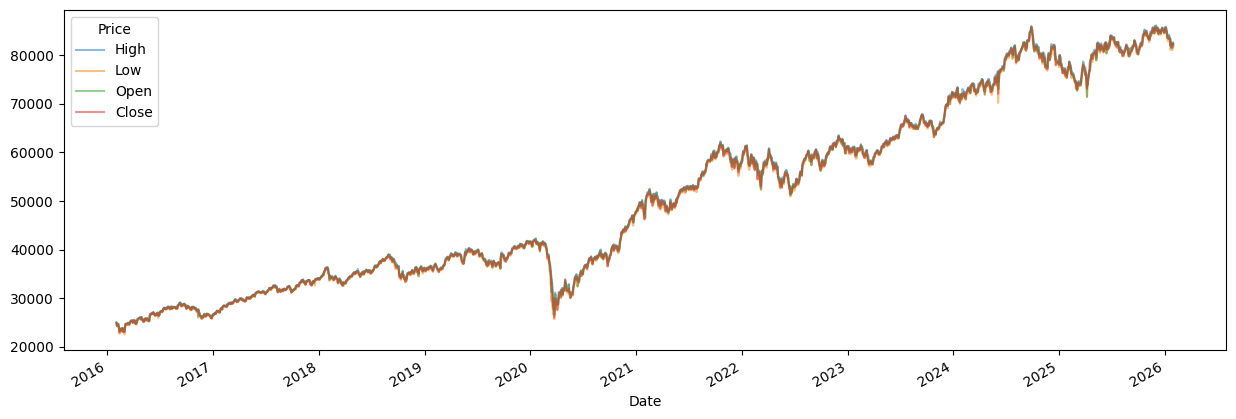

In [32]:
df[['High','Low','Open','Close']].plot(figsize = (15, 5), alpha = 0.5)

In [33]:
ts = df['High']

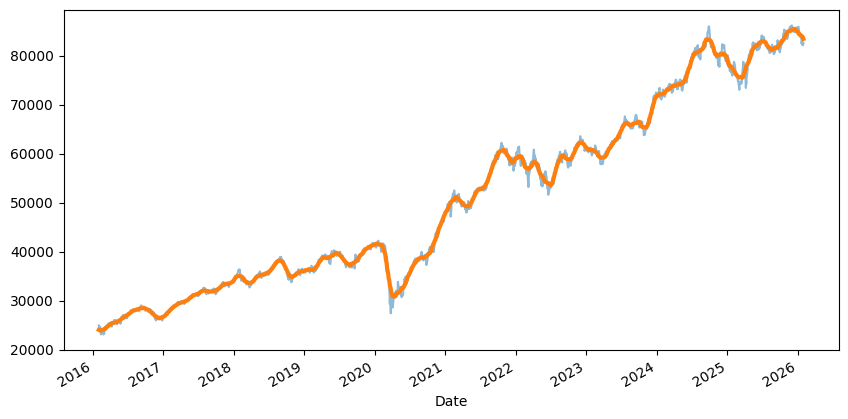

In [34]:
trend = ts.rolling(
    window=30,
    center=True,
    min_periods=15
).mean()

ax = ts.plot(alpha=0.5)
ax = trend.plot(ax=ax, linewidth=3)

<Axes: >

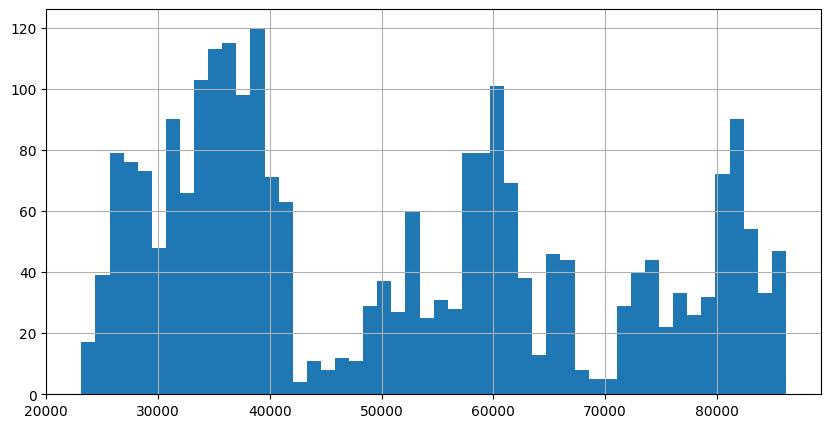

In [35]:
df.High.hist(bins=50)

In [37]:
from statistics import stdev
mean=[]
std=[]
    
for i in range(0,10):
    mean.append(df['High'].iloc[(i*182):(i*182)+182].mean())
    std.append(stdev(df['High'].iloc[(i*182):(i*182)+182]))

In [38]:
pd.concat([pd.DataFrame(mean,columns=['mean']),pd.DataFrame(std,columns=['std'])], axis=1)

,mean,std
0,26632.101047,1615.453575
1,29009.245589,1832.228776
2,33351.675642,1155.238141
3,36106.804537,1216.121609
4,38117.702760,1255.473710
5,37134.704456,4327.334365
6,44261.100554,5136.486343
7,55485.817973,4068.398577
8,57221.642600,2480.706539
9,60818.872360,1597.884565


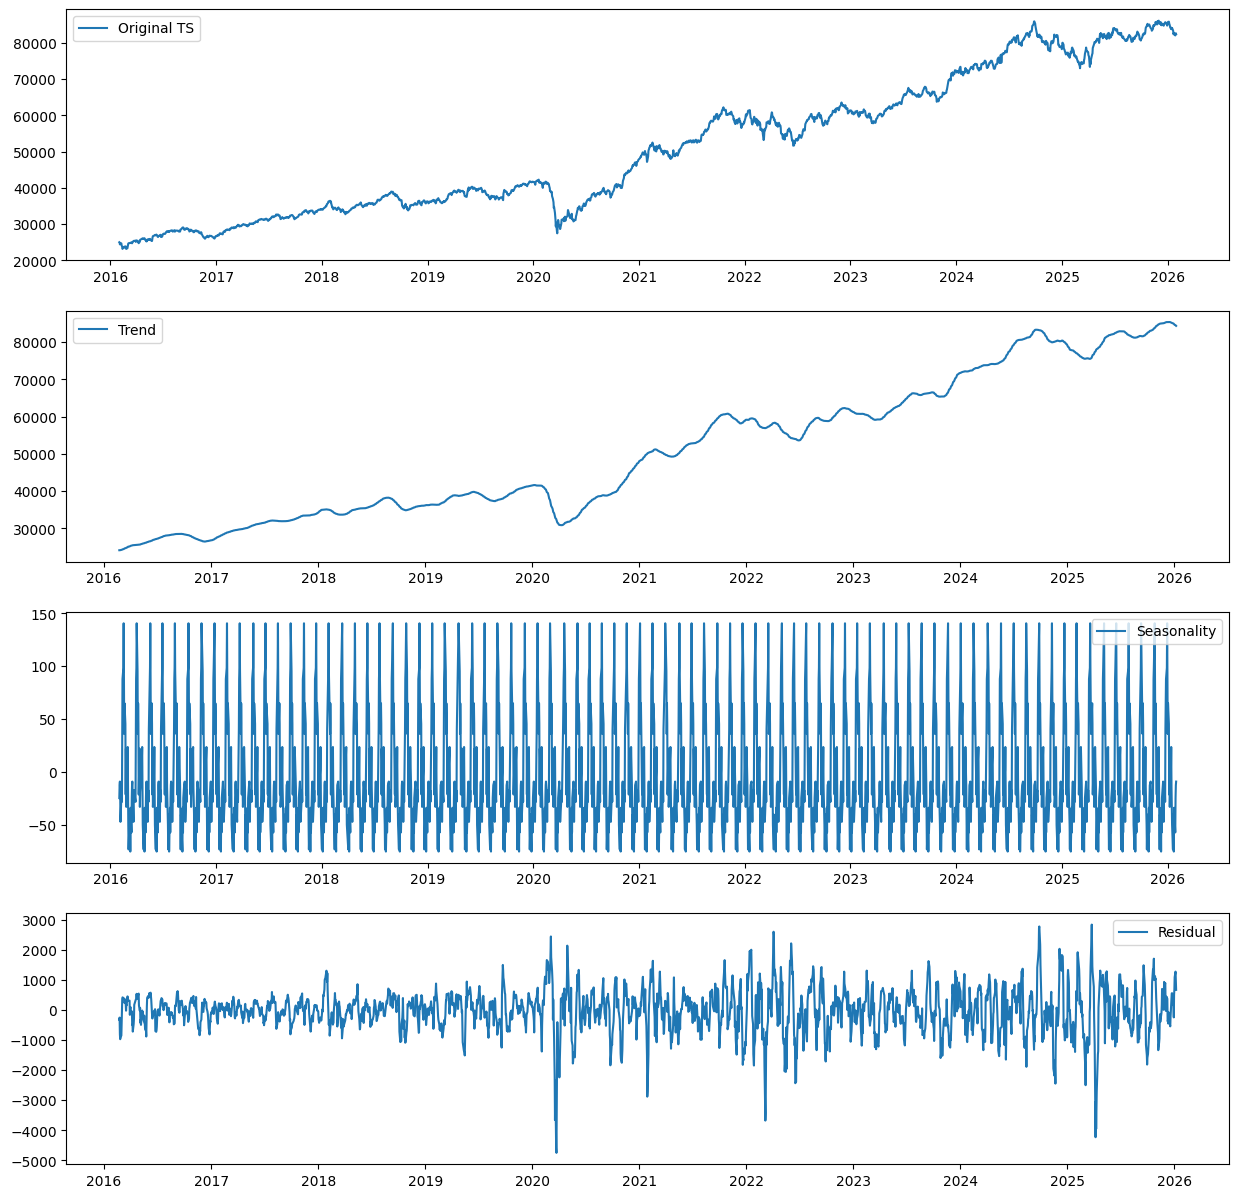

In [39]:
decompose_add=seasonal_decompose(df['High'], model='additive', period=30)
plt.figure(figsize=(15,15))
plt.subplot(411)
plt.plot(df['High'], label='Original TS')
plt.legend(loc='best')
plt.subplot(412)
plt.plot(decompose_add.trend, label='Trend')
plt.legend(loc='best')
plt.subplot(413)
plt.plot(decompose_add.seasonal,label='Seasonality')
plt.legend(loc='best')
plt.subplot(414)
plt.plot(decompose_add.resid, label='Residual')
plt.legend(loc='best')

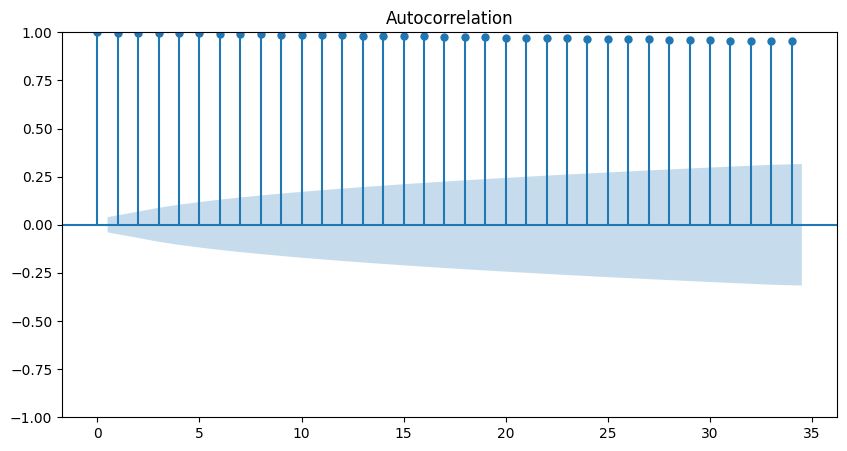

In [40]:
plt.rc("figure", figsize=(10,5))
plot_acf(df['High'])
print()

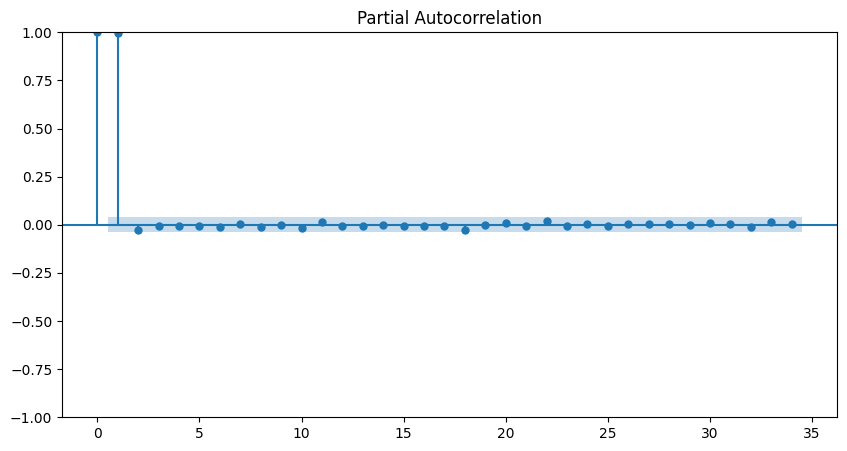

In [41]:
plt.rc("figure", figsize=(10,5))
plot_pacf(df['High'])
print()

In [42]:
split_idx = int(0.8 * len(ts))
ts_train = ts[:split_idx]
ts_test= ts[split_idx:]

In [43]:
scaler = MinMaxScaler()
ts_train = scaler.fit_transform(ts_train.values.reshape(-1, 1))
ts_test = scaler.transform(ts_test.values.reshape(-1, 1))

In [44]:
def create_sequences(data, seq_length):
    X, y = [], []
    for i in range(len(data) - seq_length):
        X.append(data[i:i+seq_length])
        y.append(data[i+seq_length])
    return np.array(X), np.array(y)

In [45]:
seq_length = 5
X_train, y_train = create_sequences(ts_train, seq_length)
X_test, y_test = create_sequences(ts_test, seq_length)

In [46]:
print(X_train.shape, y_train.shape)
print(X_test.shape, y_test.shape)

(1965, 5, 1) (1965, 1)
(488, 5, 1) (488, 1)


In [47]:
model = Sequential([
    Input(shape=(seq_length, 1)),
    LSTM(100, return_sequences=True),
    Dropout(0.2),
    LSTM(100),
    Dropout(0.2),
    Dense(1)
])
model.compile(optimizer='adam', loss='mse')

In [48]:
callback = EarlyStopping(patience=10, restore_best_weights=True)
history = model.fit(
    X_train, y_train,
    epochs=200,
    batch_size=64,
    validation_split=0.1,
    callbacks=[callback],
    verbose=1
)

Epoch 1/200
28/28 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - loss: 0.0385 - val_loss: 0.0310
Epoch 2/200
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0024 - val_loss: 0.0023
Epoch 3/200
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0012 - val_loss: 2.0560e-04
Epoch 4/200
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0011 - val_loss: 3.1643e-04
Epoch 5/200
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0011 - val_loss: 2.1470e-04
Epoch 6/200
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0010 - val_loss: 2.3898e-04
Epoch 7/200
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 9.8480e-04 - val_loss: 1.9270e-04
Epoch 8/200
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0010 - val_loss: 5.2799e-04
Epoch 9/200
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0010 - val_loss: 5.2574e-04
Epoch 10/200
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 9.7301e-04 - val_loss: 7.1264e-04
Epoch 11/200
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 9.4946e-04 - val_loss: 5.6540e-04
Epoch 12/200
2

In [49]:
train_pred = model.predict(X_train)
test_pred = model.predict(X_test)

train_pred = scaler.inverse_transform(train_pred)
test_pred = scaler.inverse_transform(test_pred)
y_train_orig = scaler.inverse_transform(y_train.reshape(-1, 1))
y_test_orig = scaler.inverse_transform(y_test.reshape(-1, 1))

62/62 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step


In [50]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

def evaluate(actual, predicted):
    mse = mean_squared_error(actual, predicted)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(actual, predicted)
    r2 = r2_score(actual, predicted)
    return mse, rmse, mae, r2


In [51]:
train_mse, train_rmse, train_mae, train_r2 = evaluate(y_train_orig, train_pred)
test_mse, test_rmse, test_mae, test_r2 = evaluate(y_test_orig, test_pred)

print(f"Train -> RMSE: {train_rmse:.4f}, MAE: {train_mae:.4f}, MSE: {train_mse:.4f}, R2: {train_r2:.4f}")
print(f"Test  -> RMSE: {test_rmse:.4f}, MAE: {test_mae:.4f}, MSE: {test_mse:.4f}, R2: {test_r2:.4f}")

Train -> RMSE: 723.3144, MAE: 505.5405, MSE: 523183.7237, R2: 0.9970
Test  -> RMSE: 1075.9531, MAE: 875.3394, MSE: 1157675.1448, R2: 0.9185


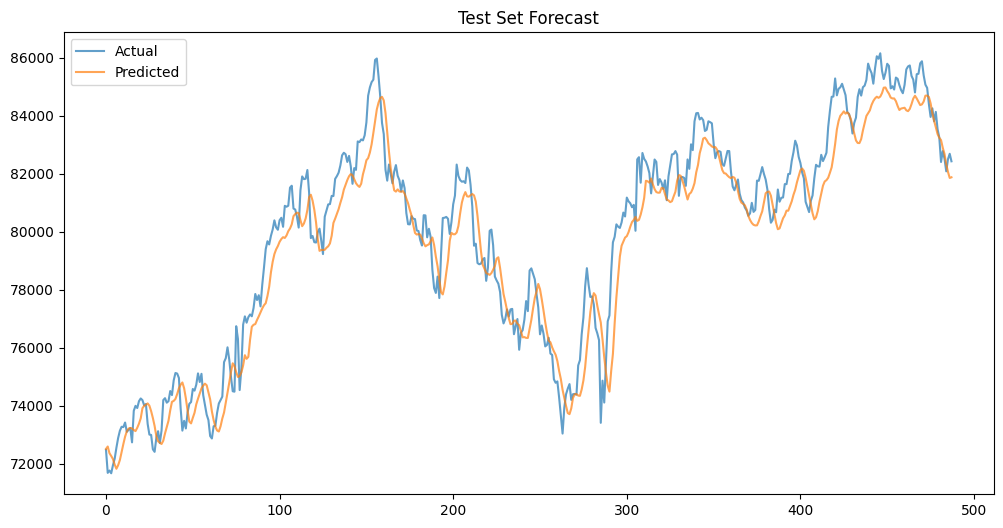

In [52]:
plt.figure(figsize=(12, 6))
plt.plot(y_test_orig, label='Actual', alpha=0.7)
plt.plot(test_pred, label='Predicted', alpha=0.7)
plt.legend()
plt.title("Test Set Forecast")
plt.show()

In [53]:
from tensorflow.keras.optimizers import Adam

model = Sequential([
    Input(shape=(seq_length, 1)),
    LSTM(100, return_sequences=True,),
    Dropout(0.2),
    LSTM(100,),
    Dropout(0.2),
    Dense(100),
    Dropout(0.2),
    Dense(25),
    Dense(1),
])
opt1=Adam(learning_rate=0.001,beta_1=0.9,beta_2=0.999)
model.compile(optimizer=opt1, loss='mse')

In [54]:
callback = EarlyStopping(patience=10, restore_best_weights=True)
history = model.fit(
    X_train, y_train,
    epochs=200,
    batch_size=64,
    validation_split=0.1,
    callbacks=[callback],
    verbose=1
)

Epoch 1/200
28/28 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - loss: 0.0307 - val_loss: 0.0011
Epoch 2/200
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0025 - val_loss: 2.4116e-04
Epoch 3/200
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0022 - val_loss: 6.3274e-04
Epoch 4/200
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0016 - val_loss: 4.0074e-04
Epoch 5/200
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0014 - val_loss: 3.4511e-04
Epoch 6/200
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0015 - val_loss: 2.2239e-04
Epoch 7/200
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0013 - val_loss: 3.6265e-04
Epoch 8/200
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0012 - val_loss: 2.8178e-04
Epoch 9/200
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0012 - val_loss: 1.7470e-04
Epoch 10/200
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0010 - val_loss: 5.9449e-04
Epoch 11/200
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 9.7897e-04 - val_loss: 2.5298e-04
Epoch 12/200
28/28

In [55]:
train_pred = model.predict(X_train)
test_pred = model.predict(X_test)

train_pred = scaler.inverse_transform(train_pred)
test_pred = scaler.inverse_transform(test_pred)
y_train_orig = scaler.inverse_transform(y_train.reshape(-1, 1))
y_test_orig = scaler.inverse_transform(y_test.reshape(-1, 1))

62/62 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step


In [56]:
train_mse, train_rmse, train_mae, train_r2 = evaluate(y_train_orig, train_pred)
test_mse, test_rmse, test_mae, test_r2 = evaluate(y_test_orig, test_pred)

print(f"Train -> RMSE: {train_rmse:.4f}, MAE: {train_mae:.4f}, MSE: {train_mse:.4f}, R2: {train_r2:.4f}")
print(f"Test  -> RMSE: {test_rmse:.4f}, MAE: {test_mae:.4f}, MSE: {test_mse:.4f}, R2: {test_r2:.4f}")

Train -> RMSE: 673.4147, MAE: 492.4570, MSE: 453487.3135, R2: 0.9974
Test  -> RMSE: 915.7995, MAE: 721.5369, MSE: 838688.6465, R2: 0.9410


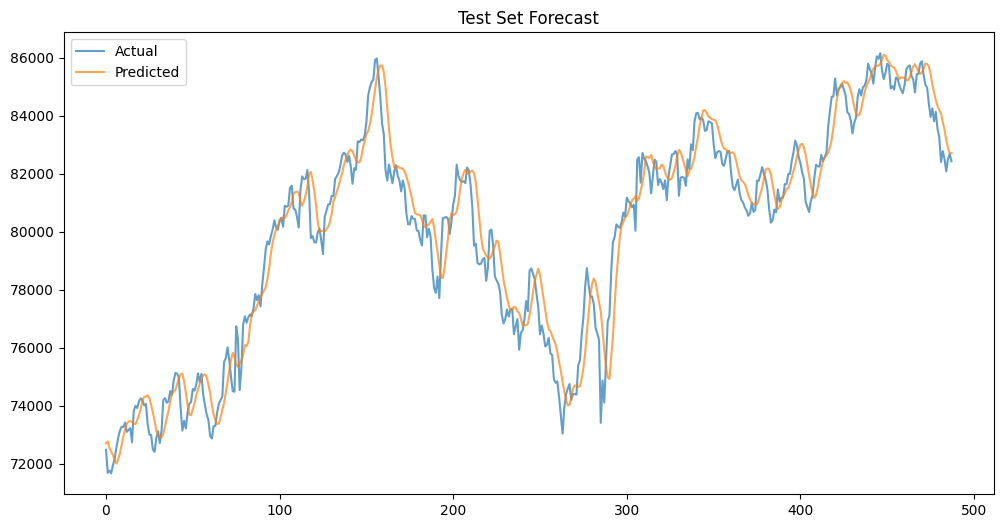

In [57]:
plt.figure(figsize=(12, 6))
plt.plot(y_test_orig, label='Actual', alpha=0.7)
plt.plot(test_pred, label='Predicted', alpha=0.7)
plt.legend()
plt.title("Test Set Forecast")
plt.show()

### Bidirectional LSTM

In [58]:
from tensorflow.keras.layers import Bidirectional
model = Sequential([
    Input(shape=(seq_length, 1)),
    Bidirectional(LSTM(200, return_sequences=True,)),
    Dropout(0.2),
    Bidirectional(LSTM(100,)),
    Dropout(0.2),
    Dense(100),
    Dropout(0.2),
    Dense(25),
    Dense(1),
])
model.compile(optimizer='adam', loss='mse')

In [59]:
callback = EarlyStopping(patience=10, restore_best_weights=True)
history = model.fit(
    X_train, y_train,
    epochs=200,
    batch_size=64,
    validation_split=0.1,
    callbacks=[callback],
    verbose=1
)

Epoch 1/200
28/28 ━━━━━━━━━━━━━━━━━━━━ 4s 23ms/step - loss: 0.0227 - val_loss: 0.0089
Epoch 2/200
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0020 - val_loss: 0.0020
Epoch 3/200
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0016 - val_loss: 2.1356e-04
Epoch 4/200
28/28 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - loss: 0.0014 - val_loss: 1.8169e-04
Epoch 5/200
28/28 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - loss: 0.0012 - val_loss: 8.2115e-04
Epoch 6/200
28/28 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - loss: 0.0012 - val_loss: 0.0017
Epoch 7/200
28/28 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - loss: 0.0012 - val_loss: 1.8389e-04
Epoch 8/200
28/28 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - loss: 0.0011 - val_loss: 2.5779e-04
Epoch 9/200
28/28 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - loss: 0.0011 - val_loss: 8.7069e-04
Epoch 10/200
28/28 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - loss: 0.0011 - val_loss: 0.0011
Epoch 11/200
28/28 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - loss: 8.9187e-04 - val_loss: 2.3090e-04
Epoch 12/200
28/28 ━

In [60]:
train_pred = model.predict(X_train)
test_pred = model.predict(X_test)

train_pred = scaler.inverse_transform(train_pred)
test_pred = scaler.inverse_transform(test_pred)
y_train_orig = scaler.inverse_transform(y_train.reshape(-1, 1))
y_test_orig = scaler.inverse_transform(y_test.reshape(-1, 1))

62/62 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step


In [61]:
train_mse, train_rmse, train_mae, train_r2 = evaluate(y_train_orig, train_pred)
test_mse, test_rmse, test_mae, test_r2 = evaluate(y_test_orig, test_pred)

print(f"Train -> RMSE: {train_rmse:.4f}, MAE: {train_mae:.4f}, MSE: {train_mse:.4f}, R2: {train_r2:.4f}")
print(f"Test  -> RMSE: {test_rmse:.4f}, MAE: {test_mae:.4f}, MSE: {test_mse:.4f}, R2: {test_r2:.4f}")

Train -> RMSE: 644.6160, MAE: 455.5381, MSE: 415529.7749, R2: 0.9976
Test  -> RMSE: 923.6024, MAE: 742.7497, MSE: 853041.4618, R2: 0.9400


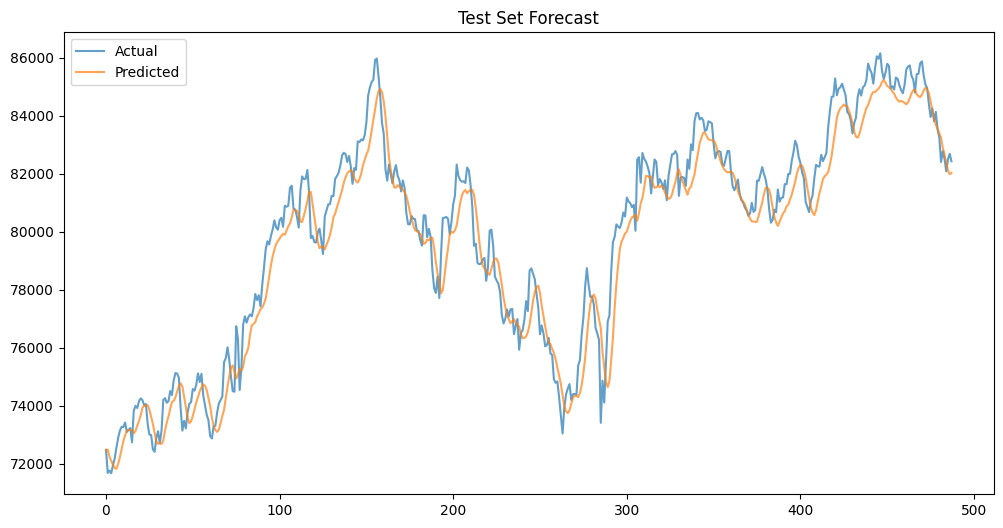

In [62]:
plt.figure(figsize=(12, 6))
plt.plot(y_test_orig, label='Actual', alpha=0.7)
plt.plot(test_pred, label='Predicted', alpha=0.7)
plt.legend()
plt.title("Test Set Forecast")
plt.show()

19:18:26 - cmdstanpy - INFO - Chain [1] start processing
19:18:27 - cmdstanpy - INFO - Chain [1] done processing


Prophet Test -> RMSE: 881.93, MAE: 699.12, MSE: 777795.44, R2: 0.9475, DA: 0.6098

Train: 2016-02-01 to 2024-01-31 (1970 rows)
Test:  2024-02-01 to 2026-01-30 (493 rows)


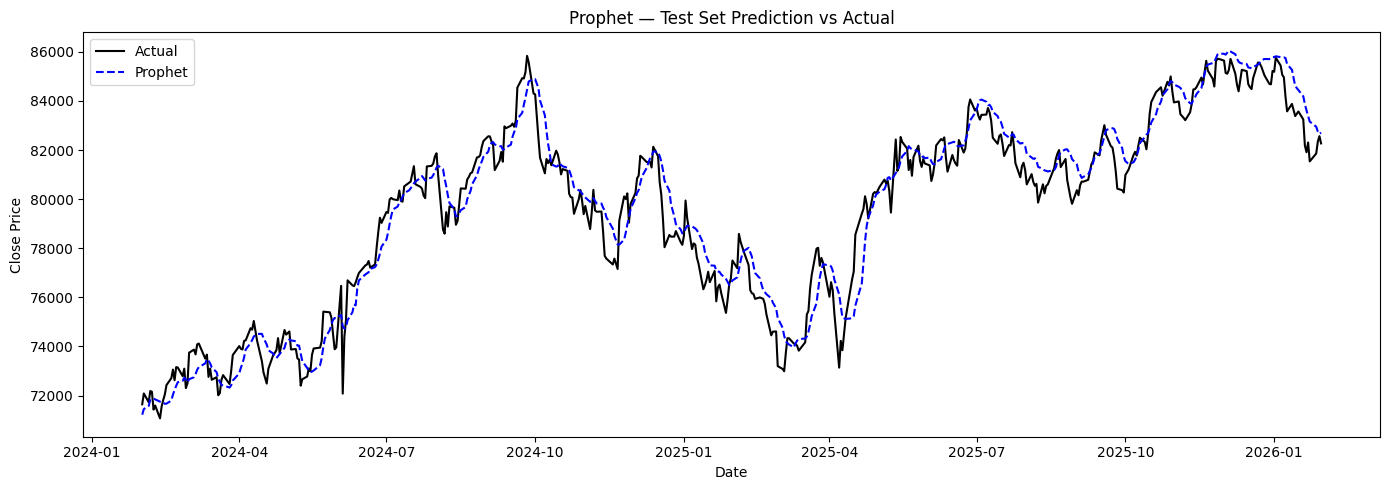

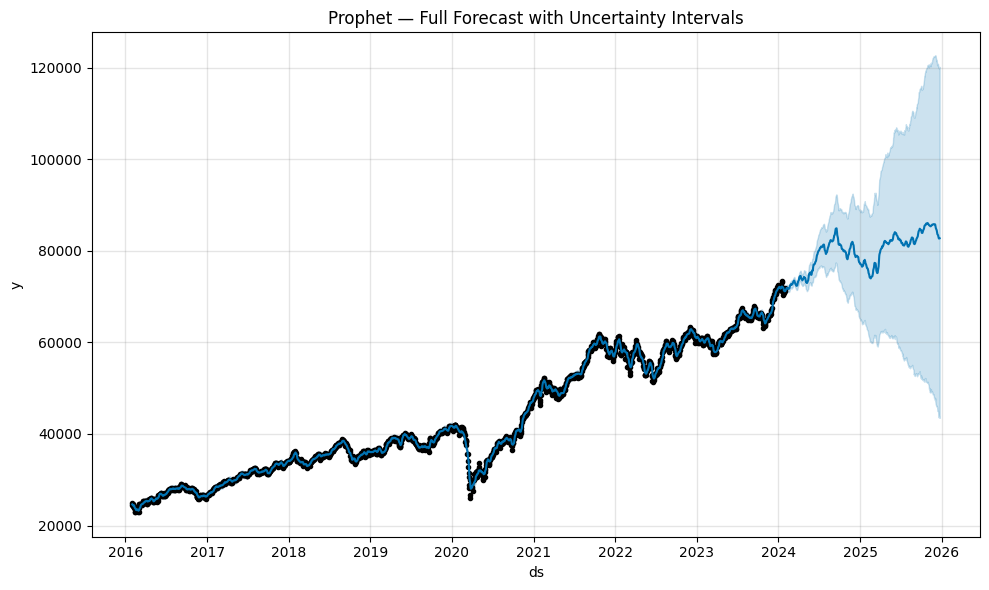

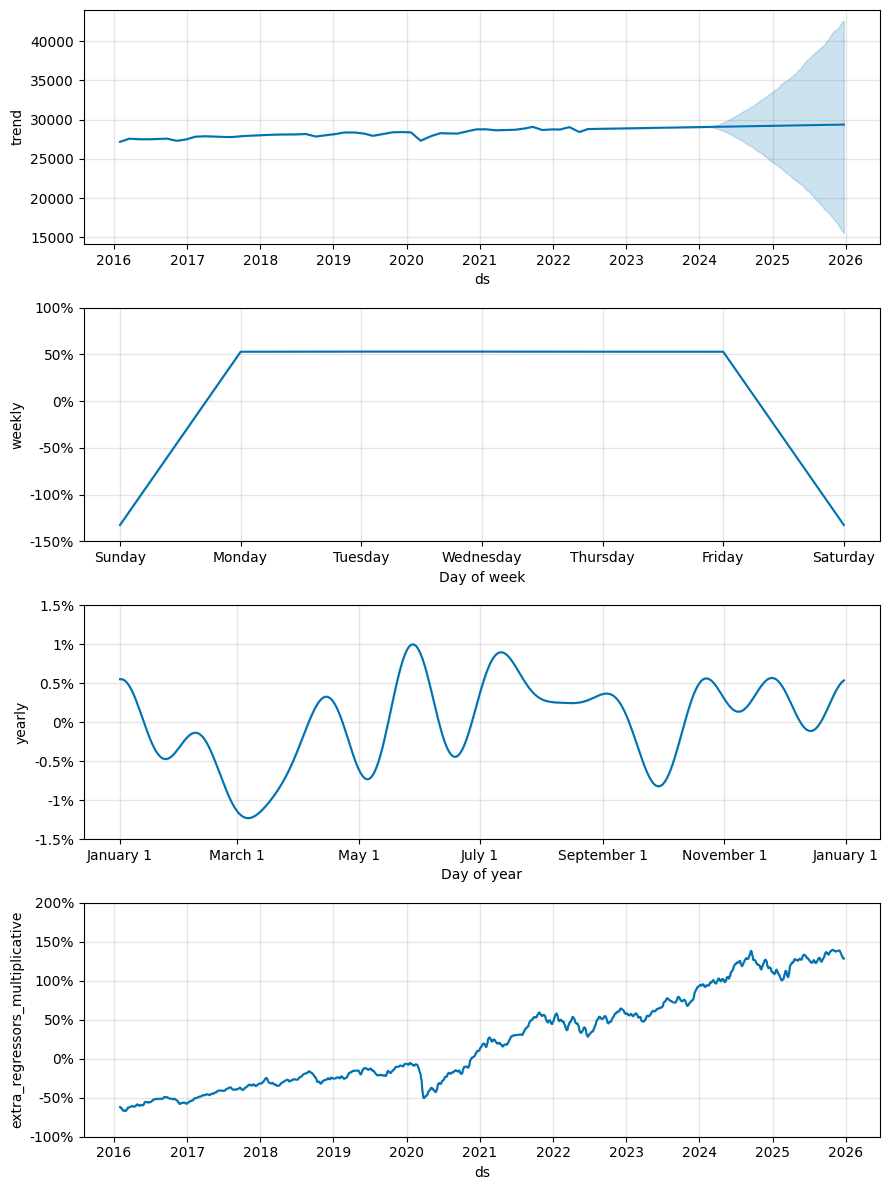

In [195]:
# ============================================================
# PROPHET MODEL (UPDATED)
# ============================================================
from prophet import Prophet
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# --- Prepare data ---
prophet_df = df[['Close']].reset_index()
prophet_df.columns = ['ds', 'y']
prophet_df['ds'] = pd.to_datetime(prophet_df['ds']).dt.tz_localize(None)

# --- Add rolling average feature ---
prophet_df['rolling_7'] = prophet_df['y'].rolling(7, min_periods=1).mean()

# --- 80/20 split ---
split_idx     = int(0.8 * len(prophet_df))
prophet_train = prophet_df[:split_idx].copy()
prophet_test  = prophet_df[split_idx:].copy()

# --- Fit Prophet ---
prophet_model = Prophet(
    daily_seasonality=False,
    weekly_seasonality=True,
    yearly_seasonality=True,
    changepoint_prior_scale=0.5,
    seasonality_prior_scale=10.0,
    seasonality_mode='multiplicative',
    n_changepoints=50
)
prophet_model.add_regressor('rolling_7')
prophet_model.fit(prophet_train)

# --- Build future dataframe ---
future = prophet_model.make_future_dataframe(periods=len(prophet_test), freq='B')
future['rolling_7'] = prophet_df['rolling_7'].values[:len(future)]

# --- Predict ---
forecast = prophet_model.predict(future)

# --- Extract test predictions ---
prophet_test_pred   = forecast['yhat'].values[-len(prophet_test):]
prophet_test_actual = prophet_test['y'].values

# --- Metrics ---
def evaluate(actual, predicted):
    mse  = mean_squared_error(actual, predicted)
    rmse = np.sqrt(mse)
    mae  = mean_absolute_error(actual, predicted)
    r2   = r2_score(actual, predicted)
    return mse, rmse, mae, r2

def directional_accuracy(actual, predicted):
    actual_dir = np.diff(actual.flatten()) > 0
    pred_dir   = np.diff(predicted.flatten()) > 0
    return np.mean(actual_dir == pred_dir)

p_mse, p_rmse, p_mae, p_r2 = evaluate(prophet_test_actual, prophet_test_pred)
p_da = directional_accuracy(prophet_test_actual, prophet_test_pred)

print(f"Prophet Test -> RMSE: {p_rmse:.2f}, MAE: {p_mae:.2f}, MSE: {p_mse:.2f}, R2: {p_r2:.4f}, DA: {p_da:.4f}")

# --- Sanity check ---
print(f"\nTrain: {prophet_train['ds'].min().date()} to {prophet_train['ds'].max().date()} ({len(prophet_train)} rows)")
print(f"Test:  {prophet_test['ds'].min().date()} to {prophet_test['ds'].max().date()} ({len(prophet_test)} rows)")

# --- Plot 1: Actual vs Predicted ---
fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(prophet_test['ds'].values, prophet_test_actual, label='Actual',   color='black')
ax.plot(prophet_test['ds'].values, prophet_test_pred,   label='Prophet',  color='blue', linestyle='--')
ax.set_title('Prophet — Test Set Prediction vs Actual')
ax.set_xlabel('Date')
ax.set_ylabel('Close Price')
ax.legend()
plt.tight_layout()
plt.show()

# --- Plot 2: Full forecast with uncertainty intervals ---
fig2 = prophet_model.plot(forecast)
plt.title('Prophet — Full Forecast with Uncertainty Intervals')
plt.tight_layout()
plt.show()

# --- Plot 3: Components (trend, weekly, yearly) ---
prophet_model.plot_components(forecast)
plt.tight_layout()
plt.show()

Error distribution — Mean: -203.79, Std: 611.56

── Point Anomaly (|z| > 2.5) ──
Alarms: 59 (12.09% of test set)


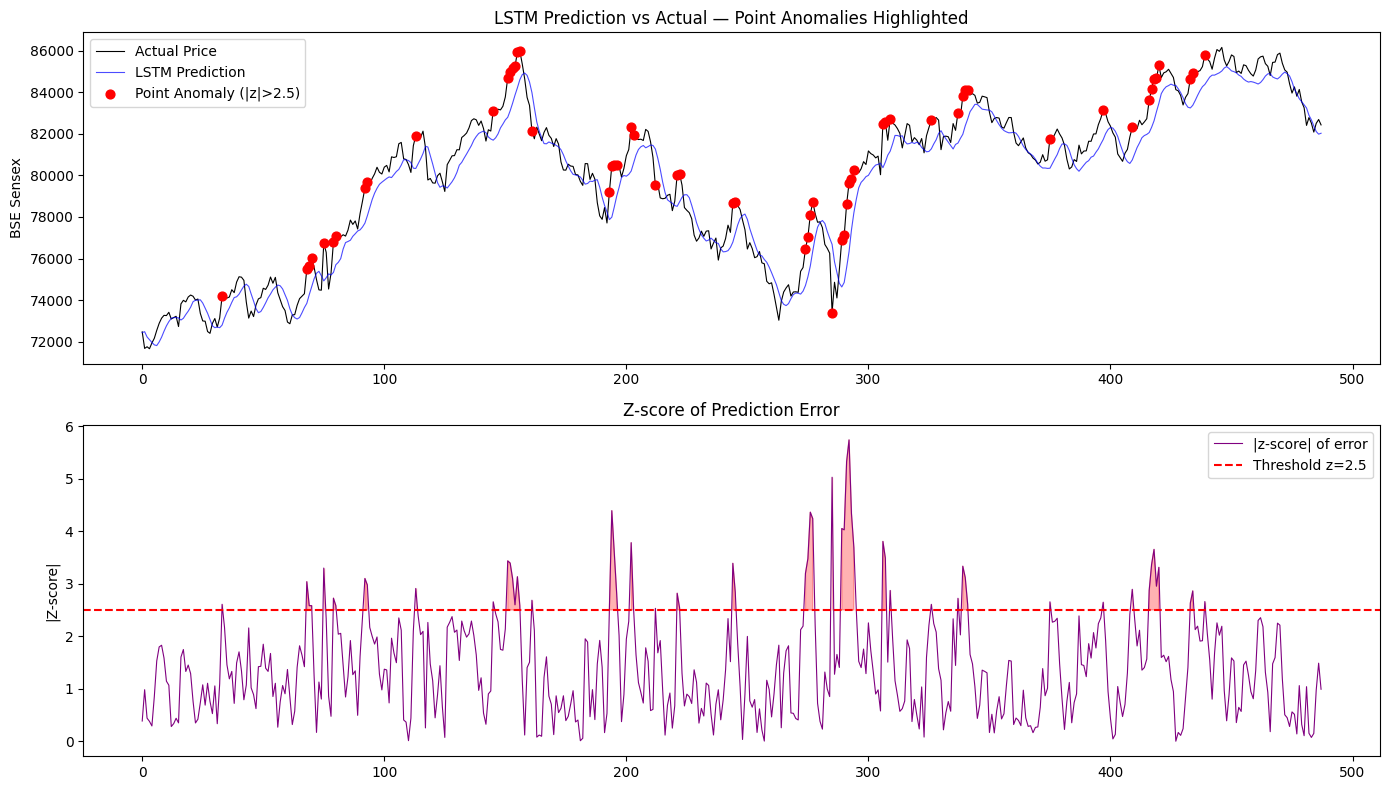


── Collective Anomaly (window=30) ──
Alarms: 51 (10.45% of test set)


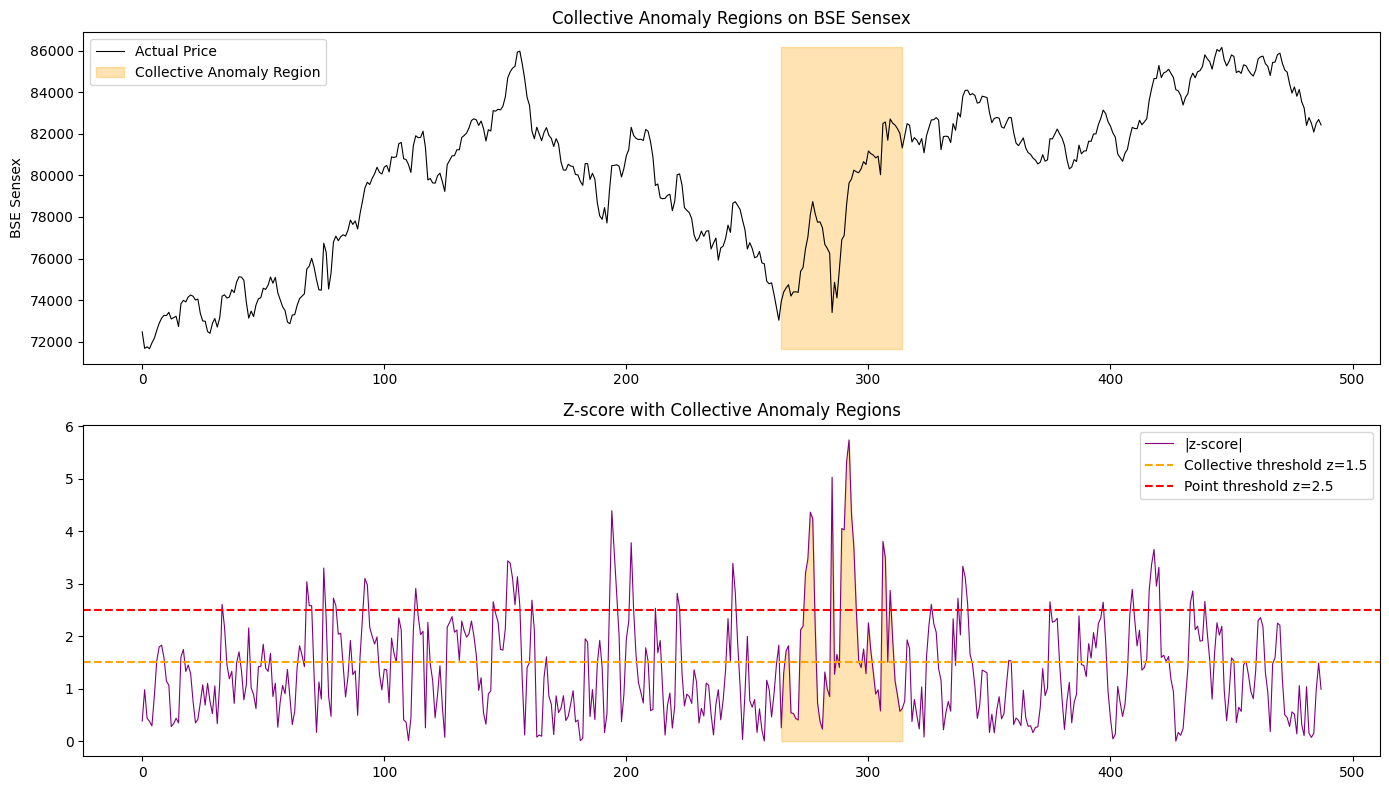


── Anomaly Detection Summary ──
Type                         Count    % of Test
-----------------------------------------------
Point Anomalies                 59       12.09%
Collective Anomalies            51       10.45%


In [63]:
# ============================================================
# ANOMALY DETECTION — IMPROVED
# ============================================================
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import multivariate_normal

# ── 1. Error vectors ─────────────────────────────────────────
E_train = (y_train_orig - train_pred).flatten()
E_test  = (y_test_orig  - test_pred).flatten()

# ── 2. Fit Gaussian on training errors ───────────────────────
mu    = E_train.mean()
sigma = E_train.std()
print(f"Error distribution — Mean: {mu:.2f}, Std: {sigma:.2f}")

# Use z-score (cleaner than raw PDF for 1D)
z_train = np.abs((E_train - mu) / sigma)
z_test  = np.abs((E_test  - mu) / sigma)

# ── 3. Point Anomaly ─────────────────────────────────────────
# Flag points where error > 2.5 standard deviations
z_threshold = 2.5
point_alarms = z_test > z_threshold

print(f"\n── Point Anomaly (|z| > {z_threshold}) ──")
print(f"Alarms: {point_alarms.sum()} ({point_alarms.mean()*100:.2f}% of test set)")

fig, axes = plt.subplots(2, 1, figsize=(14, 8))

# Plot 1: Actual price with anomaly markers
test_dates = np.arange(len(y_test_orig))
axes[0].plot(test_dates, y_test_orig.flatten(), label='Actual Price', color='black', linewidth=0.8)
axes[0].plot(test_dates, test_pred.flatten(),   label='LSTM Prediction', color='blue', linewidth=0.8, alpha=0.7)
axes[0].scatter(
    np.where(point_alarms)[0],
    y_test_orig.flatten()[point_alarms],
    color='red', marker='o', s=40, zorder=5, label=f'Point Anomaly (|z|>{z_threshold})'
)
axes[0].set_title('LSTM Prediction vs Actual — Point Anomalies Highlighted')
axes[0].set_ylabel('BSE Sensex')
axes[0].legend()

# Plot 2: Z-score over time
axes[1].plot(z_test, label='|z-score| of error', color='purple', linewidth=0.8)
axes[1].axhline(z_threshold, color='red', linestyle='--', label=f'Threshold z={z_threshold}')
axes[1].fill_between(range(len(z_test)), z_test, z_threshold,
                     where=(z_test > z_threshold), color='red', alpha=0.3)
axes[1].set_title('Z-score of Prediction Error')
axes[1].set_ylabel('|Z-score|')
axes[1].legend()

plt.tight_layout()
plt.show()

# ── 4. Collective Anomaly (fixed) ────────────────────────────
# Use MEAN z-score in window > threshold (separate, higher threshold)
window_size       = 30
z_collective_thresh = 1.5    # lower than point threshold — looks for sustained deviation
min_points_above  = 10       # at least 10/30 points must be individually anomalous

collective_alarms = np.zeros(len(z_test), dtype=bool)

for start in range(len(z_test) - window_size + 1):
    window = z_test[start:start + window_size]
    cond1  = window.mean() > z_collective_thresh          # avg z-score elevated
    cond2  = np.sum(window > z_threshold) >= min_points_above  # enough point anomalies
    if cond1 and cond2:
        collective_alarms[start:start + window_size] = True

print(f"\n── Collective Anomaly (window={window_size}) ──")
print(f"Alarms: {collective_alarms.sum()} ({collective_alarms.mean()*100:.2f}% of test set)")

fig, axes = plt.subplots(2, 1, figsize=(14, 8))

axes[0].plot(y_test_orig.flatten(), label='Actual Price', color='black', linewidth=0.8)
axes[0].fill_between(
    range(len(y_test_orig)),
    y_test_orig.flatten().min(), y_test_orig.flatten().max(),
    where=collective_alarms,
    color='orange', alpha=0.3, label='Collective Anomaly Region'
)
axes[0].set_title('Collective Anomaly Regions on BSE Sensex')
axes[0].set_ylabel('BSE Sensex')
axes[0].legend()

axes[1].plot(z_test, color='purple', linewidth=0.8, label='|z-score|')
axes[1].axhline(z_collective_thresh, color='orange', linestyle='--', label=f'Collective threshold z={z_collective_thresh}')
axes[1].axhline(z_threshold,         color='red',    linestyle='--', label=f'Point threshold z={z_threshold}')
axes[1].fill_between(range(len(z_test)), 0, z_test,
                     where=collective_alarms, color='orange', alpha=0.3)
axes[1].set_title('Z-score with Collective Anomaly Regions')
axes[1].legend()

plt.tight_layout()
plt.show()

# ── 5. Summary table ─────────────────────────────────────────
print("\n── Anomaly Detection Summary ──")
print(f"{'Type':<25} {'Count':>8} {'% of Test':>12}")
print("-" * 47)
print(f"{'Point Anomalies':<25} {point_alarms.sum():>8} {point_alarms.mean()*100:>11.2f}%")
print(f"{'Collective Anomalies':<25} {collective_alarms.sum():>8} {collective_alarms.mean()*100:>11.2f}%")

# BSE Sensex — Semantic News Similarity & Sentiment Asymmetry Analysis

Two standalone modules that plug into the main prediction pipeline:

1. **Semantic Similarity** — embed headlines into vectors, define historical crisis "anchors"  
   (2008 crash, COVID crash, etc.) and measure how close today's news is to those events  
2. **Sentiment Asymmetry** — statistically test whether negative news predicts drops  
   *better/faster* than positive news predicts rises (the well-known negativity bias in markets)


In [64]:
# Install once — comment out after first run
# !pip install sentence-transformers umap-learn hdbscan --quiet

import warnings, os
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from scipy import stats
from scipy.spatial.distance import cosine
from sklearn.preprocessing import MinMaxScaler
import yfinance as yf

print("Core imports done.")

Core imports done.


In [65]:
# ── Stock price data ─────────────────────────────────────────────────────────
price_raw = yf.download('^BSESN', start='2016-01-31', end='2026-01-31',
                        auto_adjust=False)
price_raw.columns = price_raw.columns.get_level_values(0)
price_df = price_raw.reset_index()
price_df = price_df.drop(columns=['Adj Close'])
price_df['Date'] = pd.to_datetime(price_df['Date'])

# Daily log return
price_df = price_df.sort_values('Date').reset_index(drop=True)
price_df['LogReturn'] = np.log(price_df['Close'] / price_df['Close'].shift(1))
price_df['Return_5d'] = price_df['Close'].pct_change(5)   # 5-day forward context
price_df = price_df.dropna().reset_index(drop=True)

print(f"Price data : {price_df.shape}  |  {price_df['Date'].min().date()} → {price_df['Date'].max().date()}")
price_df.head(3)

[*********************100%***********************]  1 of 1 completed

Price data : (2458, 8)  |  2016-02-08 → 2026-01-30


Price,Date,Close,High,Low,Open,Volume,LogReturn,Return_5d
0,2016-02-08,24287.419922,24698.949219,24196.839844,24637.410156,11700,-0.013478,-0.021648
1,2016-02-09,24020.980469,24111.189453,23919.470703,24076.849609,11500,-0.011031,-0.021110
2,2016-02-10,23758.900391,23938.320312,23636.720703,23938.320312,19400,-0.010970,-0.019172


In [66]:
# ── News headlines ───────────────────────────────────────────────────────────
HEADLINES_PATH = "india-news-headlines.csv"   # ← update if needed

news_raw = pd.read_csv(HEADLINES_PATH)
news_raw['date'] = pd.to_datetime(news_raw['publish_date'], format='%Y%m%d')
news_raw = news_raw.drop(columns=['publish_date', 'headline_category'], errors='ignore')
news_raw = news_raw.rename(columns={'headline_text': 'headline'})

# Aggregate all headlines for each day into one document
news_daily = (news_raw
              .groupby('date')['headline']
              .apply(lambda x: ' '.join(x))
              .reset_index())

print(f"News data  : {news_daily.shape}  |  {news_daily['date'].min().date()} → {news_daily['date'].max().date()}")
news_daily.head(3)

News data  : (8170, 2)  |  2001-01-02 → 2023-06-30


,date,headline
0,2001-01-02,Status quo will not be disturbed at Ayodhya; s...
1,2001-01-03,Powerless north India gropes in the dark Think...
2,2001-01-04,The string that pulled Stephen Hawking to Indi...


In [67]:
# ── Merge price + news on date ───────────────────────────────────────────────
merged = pd.merge(
    price_df[['Date', 'Close', 'LogReturn', 'Return_5d']],
    news_daily.rename(columns={'date': 'Date'}),
    on='Date', how='inner'
).sort_values('Date').reset_index(drop=True)

print(f"Merged rows : {len(merged)}")
print(f"Date range  : {merged['Date'].min().date()} → {merged['Date'].max().date()}")
merged.head(3)

Merged rows : 1819
Date range  : 2016-02-08 → 2023-06-30


,Date,Close,LogReturn,Return_5d,headline
0,2016-02-08,24287.419922,-0.013478,-0.021648,Monday hangovers: Healthy recipes for hangover...
1,2016-02-09,24020.980469,-0.011031,-0.021110,Exercises to treat lower back ache Important d...
2,2016-02-10,23758.900391,-0.010970,-0.019172,Decoding headaches: Top 20 types of headaches ...


In [70]:
# ── Load sentence embedding model ────────────────────────────────────────────
from sentence_transformers import SentenceTransformer

print("Loading embedding model (downloads ~90MB on first run)...")
embedder = SentenceTransformer('all-MiniLM-L6-v2')
print("Model loaded.")

# Quick sanity check
test_sentences = [
    "stock market crash bank collapse recession",
    "economic growth GDP rises bull market rally",
    "RBI cuts interest rates inflation falls",
]
test_embs = embedder.encode(test_sentences)
print(f"\nEmbedding shape per sentence : {test_embs[0].shape}")
print(f"Crash vs rally similarity    : {1 - cosine(test_embs[0], test_embs[1]):.3f}  (expect low)")
print(f"Crash vs RBI cut similarity  : {1 - cosine(test_embs[0], test_embs[2]):.3f}  (expect medium)")

Loading embedding model (downloads ~90MB on first run)...
Model loaded.

Embedding shape per sentence : (384,)
Crash vs rally similarity    : 0.379  (expect low)
Crash vs RBI cut similarity  : 0.350  (expect medium)


In [71]:
# ══════════════════════════════════════════════════════════════════════════════
#  CRISIS ANCHORS
#  These are short text descriptions of what the news SOUNDS LIKE during
#  each major market event. The more descriptive, the better the signal.
# ══════════════════════════════════════════════════════════════════════════════

CRISIS_ANCHORS = {

    # ── Global financial events ───────────────────────────────────────────────
    'Global_Financial_Crisis_2008': (
        "bank collapse lehman brothers subprime mortgage crisis credit crunch "
        "financial system collapse recession unemployment housing market crash "
        "federal reserve bailout toxic assets wall street panic"
    ),
    'COVID_Crash_2020': (
        "coronavirus pandemic lockdown economic shutdown businesses closed "
        "global recession unemployment surge supply chain disruption "
        "government stimulus relief package virus spread deaths healthcare crisis"
    ),
    'European_Debt_Crisis_2011': (
        "eurozone debt crisis greece default sovereign debt austerity measures "
        "IMF bailout portugal ireland spain bond yields surge euro collapse"
    ),

    # ── India-specific events ─────────────────────────────────────────────────
    'India_Demonetization_2016': (
        "demonetization currency ban rupee notes invalid cash shortage "
        "ATM queues black money Modi announcement economy slowdown"
    ),
    'India_IL&FS_Crisis_2018': (
        "NBFC crisis IL&FS default liquidity crunch shadow banking "
        "mutual fund redemption credit market freeze India financial stress"
    ),
    'India_Budget_Shock': (
        "union budget tax hike fiscal deficit surcharge capital gains "
        "market reaction budget disappointment foreign investors sell off"
    ),

    # ── Positive / bull market anchors ────────────────────────────────────────
    'Bull_Market_Rally': (
        "economic recovery growth GDP expansion corporate earnings beat "
        "foreign investment inflow market rally all time high optimism "
        "RBI rate cut stimulus infrastructure spending"
    ),
    'India_Reform_Euphoria': (
        "GST reform infrastructure development Make in India FDI surge "
        "ease of doing business Modi government policy reform bull run "
        "market rally foreign investment positive outlook"
    ),
}

# Embed all anchor texts
anchor_names = list(CRISIS_ANCHORS.keys())
anchor_texts  = list(CRISIS_ANCHORS.values())
anchor_embeddings = embedder.encode(anchor_texts, show_progress_bar=False)

print(f"Anchors defined   : {len(CRISIS_ANCHORS)}")
print(f"Anchor embed shape: {anchor_embeddings.shape}")
for name in anchor_names:
    print(f"  • {name}")

Anchors defined   : 8
Anchor embed shape: (8, 384)
  • Global_Financial_Crisis_2008
  • COVID_Crash_2020
  • European_Debt_Crisis_2011
  • India_Demonetization_2016
  • India_IL&FS_Crisis_2018
  • India_Budget_Shock
  • Bull_Market_Rally
  • India_Reform_Euphoria


In [72]:
# ── Embed all daily headlines (batch for speed) ──────────────────────────────
print(f"Embedding {len(merged)} days of headlines...")
print("(This takes ~2-5 minutes depending on hardware)\n")

headline_embeddings = embedder.encode(
    merged['headline'].tolist(),
    batch_size=64,
    show_progress_bar=True,
    convert_to_numpy=True
)

print(f"\nHeadline embeddings shape: {headline_embeddings.shape}")

Embedding 1819 days of headlines...
(This takes ~2-5 minutes depending on hardware)



Batches:   0%|          | 0/29 [00:00<?, ?it/s]


Headline embeddings shape: (1819, 384)


In [73]:
# ── Compute cosine similarity for each day vs each anchor ────────────────────
from sklearn.metrics.pairwise import cosine_similarity

# Shape: (n_days, n_anchors)
sim_matrix = cosine_similarity(headline_embeddings, anchor_embeddings)
sim_df = pd.DataFrame(sim_matrix, columns=anchor_names)

# Attach to merged dataframe
for col in anchor_names:
    merged[f'sim_{col}'] = sim_df[col].values

# Composite crisis score = mean of all negative anchor similarities
negative_anchors = [c for c in anchor_names if 'Bull' not in c and 'Reform' not in c]
positive_anchors = ['sim_Bull_Market_Rally', 'sim_India_Reform_Euphoria']

merged['crisis_sim_score'] = merged[[f'sim_{a}' for a in negative_anchors]].mean(axis=1)
merged['bull_sim_score']   = merged[positive_anchors].mean(axis=1)
merged['sentiment_gap']    = merged['bull_sim_score'] - merged['crisis_sim_score']

print("Similarity columns added:")
print(merged[[c for c in merged.columns if 'sim_' in c or 'score' in c]].describe().round(4))

Similarity columns added:
       sim_Global_Financial_Crisis_2008  sim_COVID_Crash_2020  \
count                         1819.0000             1819.0000   
mean                             0.1101                0.0914   
std                              0.0631                0.0970   
min                             -0.0696               -0.1211   
25%                              0.0664                0.0220   
50%                              0.1099                0.0752   
75%                              0.1522                0.1430   
max                              0.3139                0.4728   

       sim_European_Debt_Crisis_2011  sim_India_Demonetization_2016  \
count                      1819.0000                      1819.0000   
mean                          0.0050                         0.1897   
std                           0.0589                         0.0695   
min                          -0.1837                        -0.0459   
25%                          -0.0

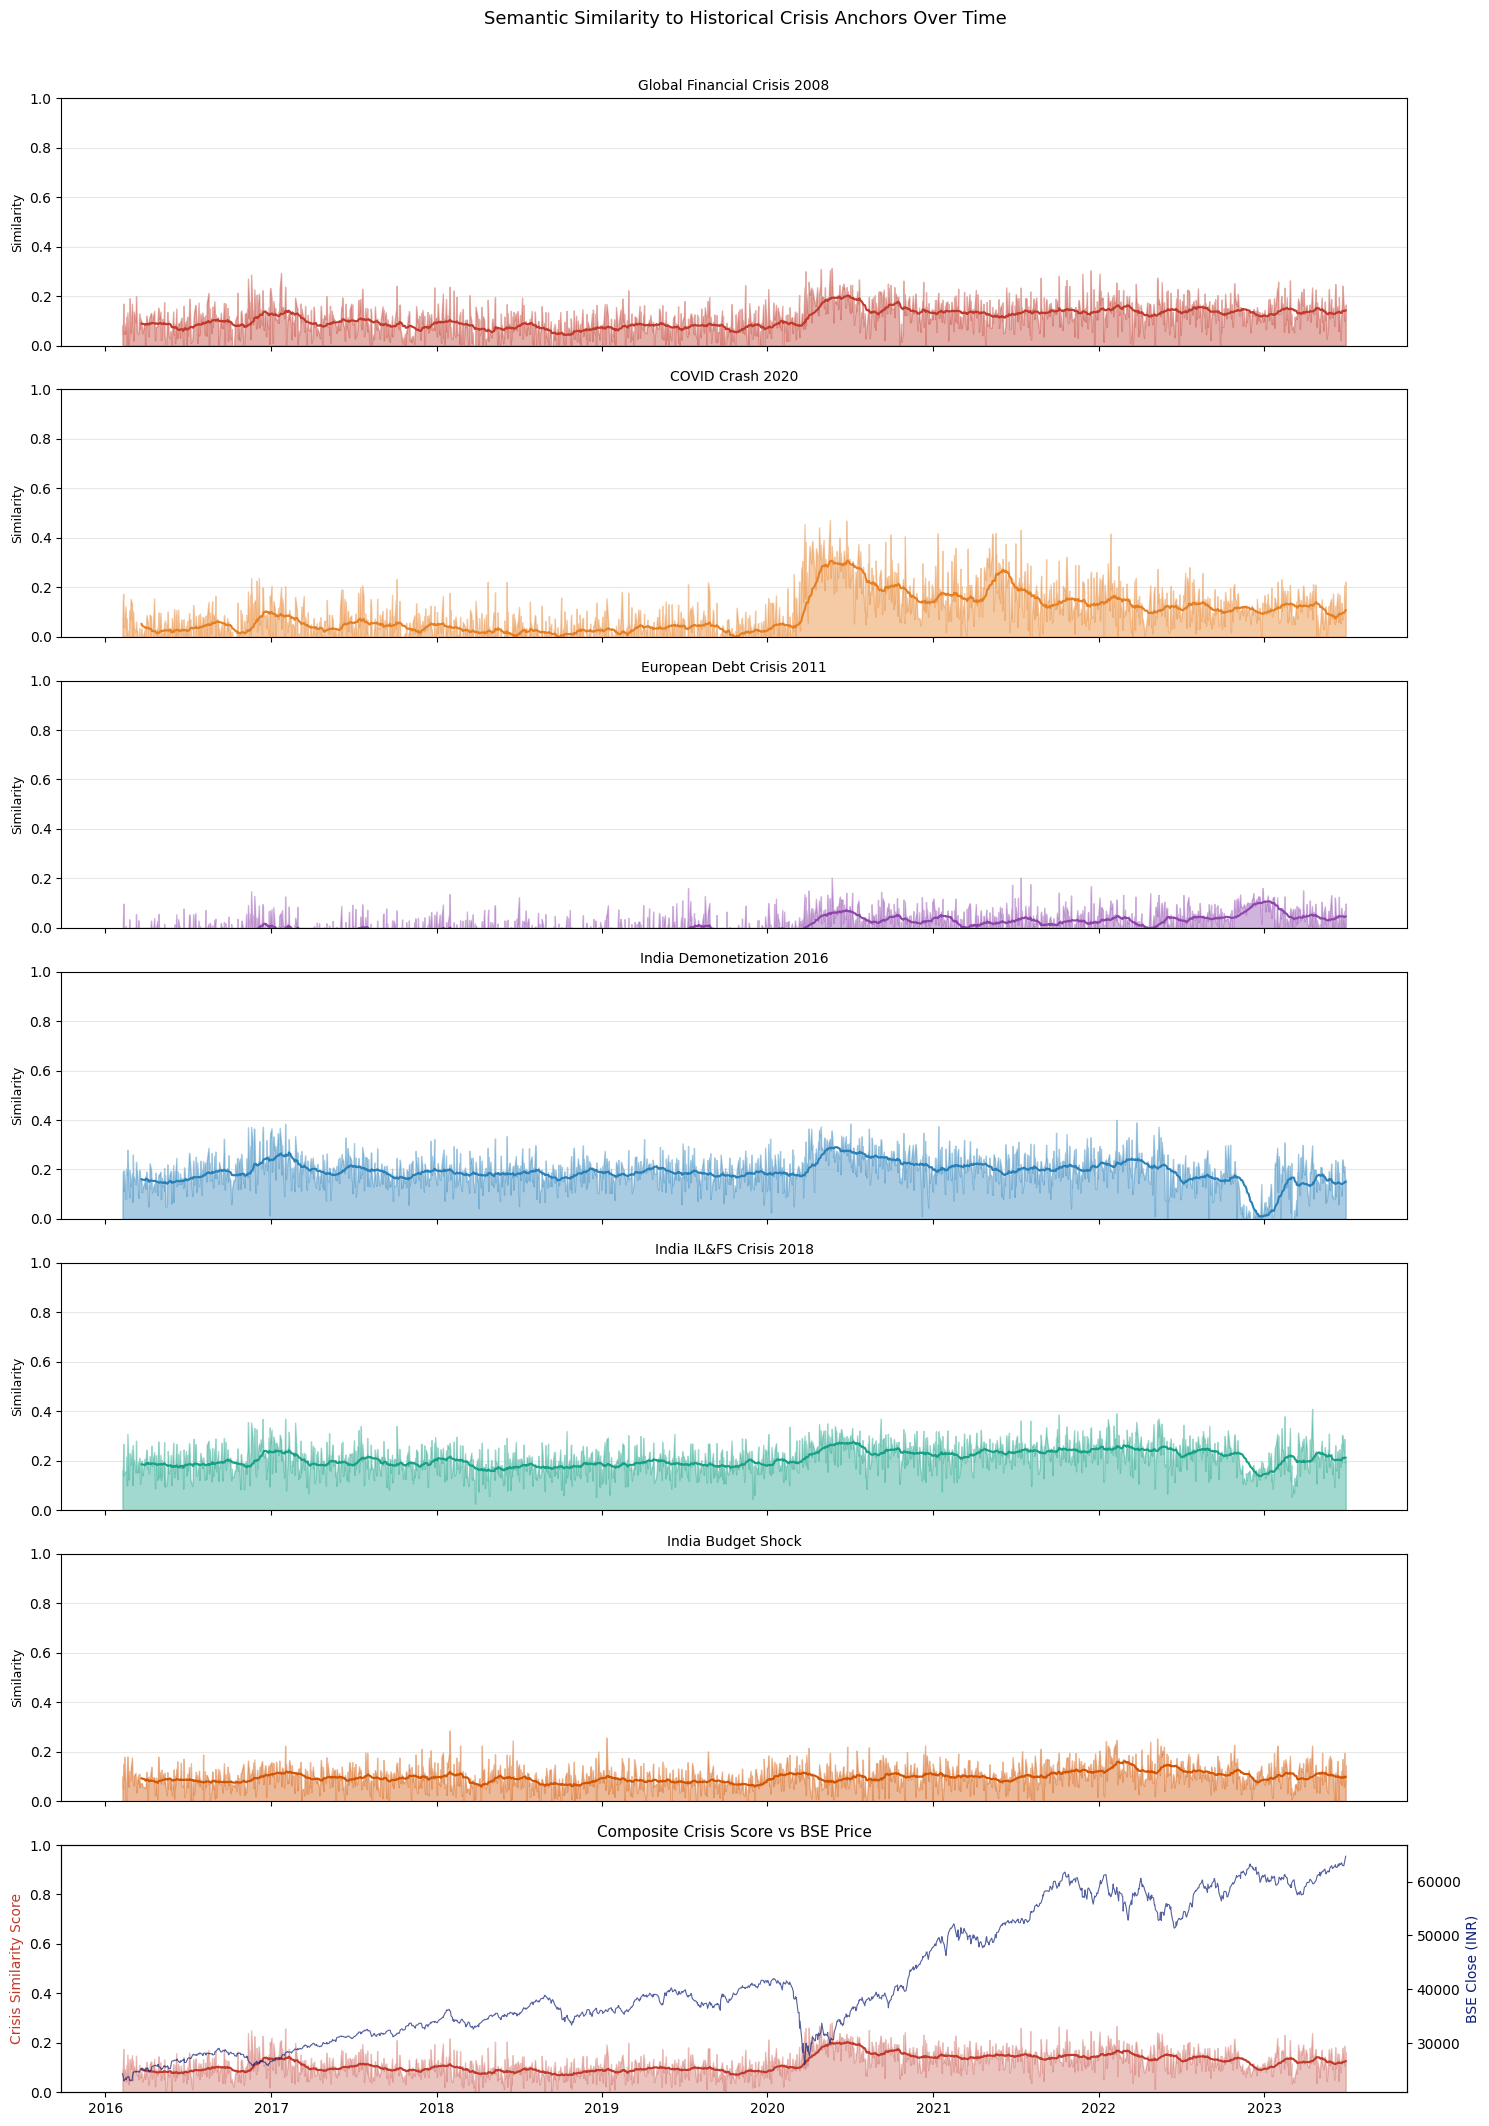

In [74]:
# ══════════════════════════════════════════════════════════════════════════════
#  VISUALISATION 1 — Crisis similarity over time
# ══════════════════════════════════════════════════════════════════════════════

fig, axes = plt.subplots(len(negative_anchors) + 1, 1,
                          figsize=(15, 3 * (len(negative_anchors) + 1)),
                          sharex=True)

# Individual anchor similarities
colors = ['#c0392b','#e67e22','#8e44ad','#2980b9','#16a085','#d35400']
for ax, anchor, color in zip(axes[:-1], negative_anchors, colors):
    sim_col = f'sim_{anchor}'
    ax.fill_between(merged['Date'], merged[sim_col],
                    alpha=0.4, color=color)
    ax.plot(merged['Date'], merged[sim_col].rolling(30).mean(),
            color=color, linewidth=1.5)
    ax.set_ylabel('Similarity', fontsize=9)
    ax.set_title(anchor.replace('_', ' '), fontsize=10)
    ax.set_ylim(0, 1)
    ax.grid(axis='y', alpha=0.3)

# Composite score + price
ax_comp = axes[-1]
ax2 = ax_comp.twinx()
ax_comp.fill_between(merged['Date'], merged['crisis_sim_score'],
                     alpha=0.3, color='#c0392b', label='Crisis Score')
ax_comp.plot(merged['Date'], merged['crisis_sim_score'].rolling(30).mean(),
             color='#c0392b', linewidth=1.5)
ax2.plot(merged['Date'], merged['Close'], color='#0b1d78',
         linewidth=0.8, alpha=0.7, label='BSE Close')
ax_comp.set_ylabel('Crisis Similarity Score', color='#c0392b')
ax2.set_ylabel('BSE Close (INR)', color='#0b1d78')
ax_comp.set_title('Composite Crisis Score vs BSE Price', fontsize=11)
ax_comp.set_ylim(0, 1)

fig.suptitle('Semantic Similarity to Historical Crisis Anchors Over Time',
             fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig('semantic_similarity_over_time.png', dpi=150, bbox_inches='tight')
plt.show()

Top 20 most crisis-similar days:
      Date        Close  LogReturn  crisis_sim_score
2020-05-22 30672.589844  -0.008451          0.281799
2020-05-18 30028.980469  -0.034972          0.276157
2020-04-24 31327.220703  -0.016961          0.270222
2022-02-09 58465.968750   0.011308          0.268100
2021-10-05 59744.878906   0.007486          0.266339
2020-04-01 28265.310547  -0.041686          0.261965
2020-04-28 32114.519531   0.011633          0.261758
2021-07-13 52769.730469   0.007552          0.260530
2020-03-25 28535.779297   0.067468          0.259321
2017-02-01 28141.640625   0.017409          0.258003
2021-10-22 60821.621094  -0.001674          0.254623
2020-08-12 38369.628906  -0.000974          0.252764
2016-11-18 26150.240234  -0.002955          0.250885
2021-12-14 58117.089844  -0.002858          0.247892
2021-08-03 53823.359375   0.016348          0.247469
2022-01-03 59183.218750   0.015828          0.245498
2020-03-23 25981.240234  -0.141017          0.244539
2020-10-30 39

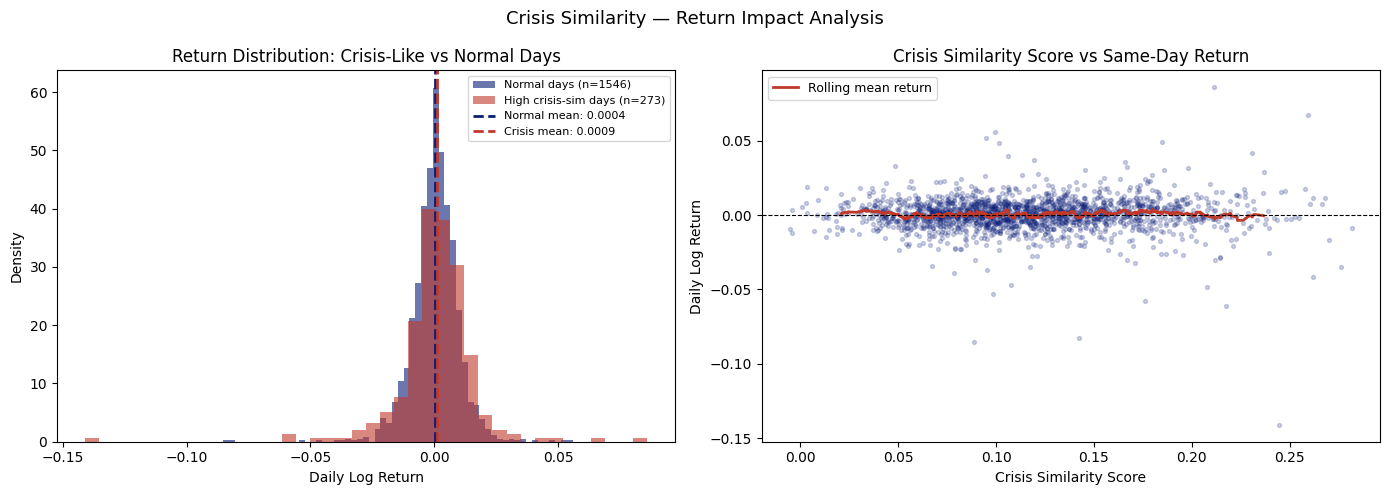


T-test: crisis vs normal days
  t-statistic : 0.6636
  p-value     : 0.507039  ❌ Not significant
  Crisis mean return : 0.000933
  Normal mean return : 0.000449


In [75]:
# ══════════════════════════════════════════════════════════════════════════════
#  VISUALISATION 2 — Top N most "crisis-like" days
# ══════════════════════════════════════════════════════════════════════════════

TOP_N = 20

top_crisis_days = (merged[['Date', 'Close', 'LogReturn', 'crisis_sim_score']]
                   .nlargest(TOP_N, 'crisis_sim_score')
                   .reset_index(drop=True))

print(f"Top {TOP_N} most crisis-similar days:")
print(top_crisis_days.to_string(index=False))

# Plot distribution of returns on high-crisis vs normal days
threshold = merged['crisis_sim_score'].quantile(0.85)   # top 15%
high_crisis = merged[merged['crisis_sim_score'] >= threshold]['LogReturn']
normal_days = merged[merged['crisis_sim_score'] <  threshold]['LogReturn']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Distribution comparison
axes[0].hist(normal_days.dropna(),   bins=60, alpha=0.6,
             color='#0b1d78', label=f'Normal days (n={len(normal_days)})', density=True)
axes[0].hist(high_crisis.dropna(),   bins=40, alpha=0.6,
             color='#c0392b', label=f'High crisis-sim days (n={len(high_crisis)})', density=True)
axes[0].axvline(normal_days.mean(), color='#0b1d78', linestyle='--', linewidth=2,
                label=f'Normal mean: {normal_days.mean():.4f}')
axes[0].axvline(high_crisis.mean(), color='#c0392b', linestyle='--', linewidth=2,
                label=f'Crisis mean: {high_crisis.mean():.4f}')
axes[0].set_xlabel('Daily Log Return')
axes[0].set_ylabel('Density')
axes[0].set_title('Return Distribution: Crisis-Like vs Normal Days')
axes[0].legend(fontsize=8)

# Similarity score vs next-day return scatter
axes[1].scatter(merged['crisis_sim_score'], merged['LogReturn'],
                alpha=0.2, s=8, color='#0b1d78')
# Rolling average line
sorted_m = merged.sort_values('crisis_sim_score')
rolling_ret = sorted_m['LogReturn'].rolling(50, center=True).mean()
axes[1].plot(sorted_m['crisis_sim_score'], rolling_ret,
             color='#c0392b', linewidth=2, label='Rolling mean return')
axes[1].axhline(0, color='black', linewidth=0.8, linestyle='--')
axes[1].set_xlabel('Crisis Similarity Score')
axes[1].set_ylabel('Daily Log Return')
axes[1].set_title('Crisis Similarity Score vs Same-Day Return')
axes[1].legend(fontsize=9)

plt.suptitle('Crisis Similarity — Return Impact Analysis', fontsize=13)
plt.tight_layout()
plt.savefig('crisis_similarity_return_impact.png', dpi=150, bbox_inches='tight')
plt.show()

# Statistical test
t_stat, p_val = stats.ttest_ind(high_crisis.dropna(), normal_days.dropna())
print(f"\nT-test: crisis vs normal days")
print(f"  t-statistic : {t_stat:.4f}")
print(f"  p-value     : {p_val:.6f}  {'✅ Significant' if p_val < 0.05 else '❌ Not significant'}")
print(f"  Crisis mean return : {high_crisis.mean():.6f}")
print(f"  Normal mean return : {normal_days.mean():.6f}")

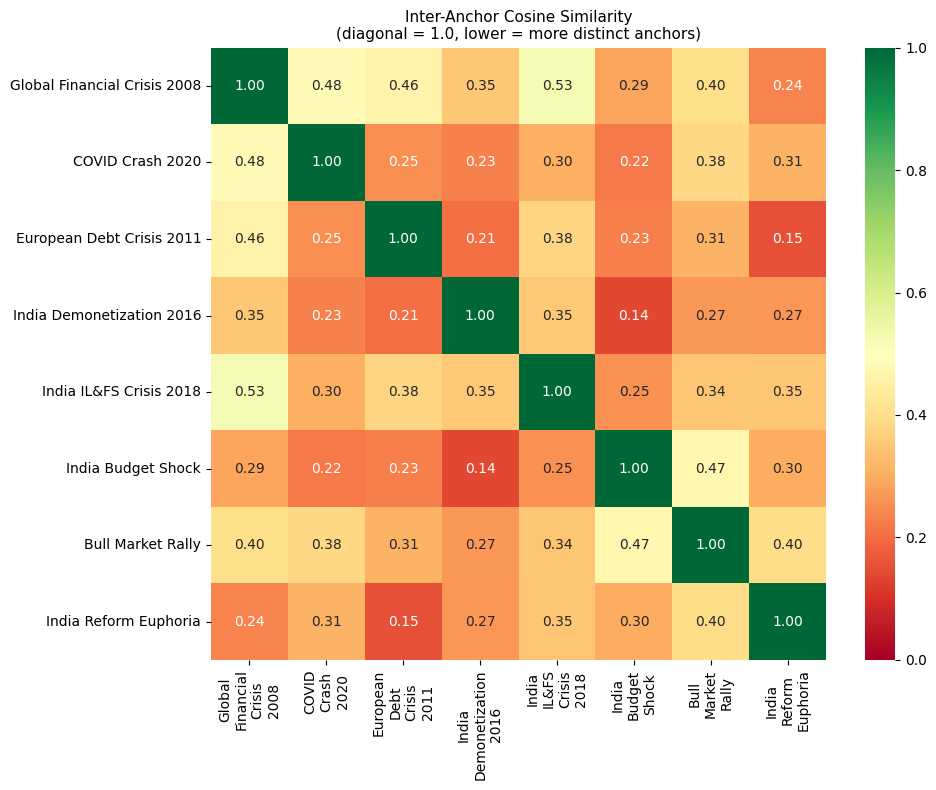

Note: anchors with similarity > 0.8 may be too similar to be independent features.


In [76]:
# ══════════════════════════════════════════════════════════════════════════════
#  VISUALISATION 3 — Anchor similarity heatmap (inter-anchor correlation)
#  Shows how distinct the anchors are from each other
# ══════════════════════════════════════════════════════════════════════════════

anchor_sim_matrix = cosine_similarity(anchor_embeddings)
anchor_sim_df = pd.DataFrame(anchor_sim_matrix,
                              index=anchor_names,
                              columns=anchor_names)

fig, ax = plt.subplots(figsize=(10, 8))
mask = np.triu(np.ones_like(anchor_sim_matrix, dtype=bool), k=1)  # upper triangle only
sns.heatmap(anchor_sim_df, annot=True, fmt='.2f', cmap='RdYlGn',
            vmin=0, vmax=1, ax=ax,
            xticklabels=[n.replace('_', '\n') for n in anchor_names],
            yticklabels=[n.replace('_', ' ') for n in anchor_names])
ax.set_title('Inter-Anchor Cosine Similarity\n(diagonal = 1.0, lower = more distinct anchors)',
             fontsize=11)
plt.tight_layout()
plt.savefig('anchor_similarity_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print("Note: anchors with similarity > 0.8 may be too similar to be independent features.")

---
## 3. Sentiment Asymmetry Analysis

### The hypothesis

Markets are widely believed to react **asymmetrically** to news:
- **Bad news** → sharp, fast, large drops  
- **Good news** → slow, gradual, moderate rises

This is called **negativity bias** or the **loss aversion effect**.  
We'll test this formally using several methods:

| Test | What it measures |
|---|---|
| Magnitude comparison | Do negative-news drops beat positive-news rises in size? |
| Speed comparison | How fast does the market react? (1d vs 5d returns) |
| Asymmetric volatility | Does bad news raise volatility more than good news lowers it? |
| Granger causality | Does sentiment *cause* price moves, or just correlate? |
| Conditional return quantiles | Distribution of returns for top/bottom sentiment days |

In [85]:
# ── Compute VADER sentiment (needed for Part 2) ───────────────────────────────
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
import re, nltk
from textblob import TextBlob, Word
nltk.download('stopwords', quiet=True)
nltk.download('wordnet',   quiet=True)

sia = SentimentIntensityAnalyzer()

def vader_scores(text):
    s = sia.polarity_scores(str(text))
    return pd.Series({
        'compound' : s['compound'],
        'pos'      : s['pos'],
        'neg'      : s['neg'],
        'neu'      : s['neu'],
    })

def textblob_scores(text):
    blob = TextBlob(str(text))
    return pd.Series({
        'polarity'     : blob.sentiment.polarity,
        'subjectivity' : blob.sentiment.subjectivity,
    })

print("Computing VADER scores...")
vader_df     = merged['headline'].apply(vader_scores)
print("Computing TextBlob scores...")
textblob_df  = merged['headline'].apply(textblob_scores)

merged = pd.concat([merged, vader_df, textblob_df], axis=1)

# Add 1-day, 3-day, 5-day FORWARD returns (what happens AFTER this news)
merged['fwd_ret_1d'] = merged['LogReturn'].shift(-1)   # tomorrow
merged['fwd_ret_3d'] = np.log(merged['Close'].shift(-3) / merged['Close'])
merged['fwd_ret_5d'] = np.log(merged['Close'].shift(-5) / merged['Close'])
merged = merged.dropna().reset_index(drop=True)

print(f"\nDataframe ready: {merged.shape}")
print(merged[['Date','compound','polarity','fwd_ret_1d','fwd_ret_3d','fwd_ret_5d']].head(4))

Computing VADER scores...
Computing TextBlob scores...

Dataframe ready: (1814, 25)
        Date  compound  polarity  fwd_ret_1d  fwd_ret_3d  fwd_ret_5d
0 2016-02-08   -0.9995  0.068477   -0.011031   -0.056561   -0.030658
1 2016-02-09   -0.9998  0.085424   -0.010970   -0.044037   -0.035122
2 2016-02-10   -0.9999  0.043660   -0.034560   -0.008656   -0.015996
3 2016-02-11   -0.9999  0.055600    0.001493    0.010408    0.029932


In [86]:
# ══════════════════════════════════════════════════════════════════════════════
#  STEP 1 — Classify days into sentiment buckets
# ══════════════════════════════════════════════════════════════════════════════

# Using VADER compound score:  > 0.05 = positive, < -0.05 = negative, else neutral
def classify_sentiment(compound):
    if compound >= 0.05:
        return 'Positive'
    elif compound <= -0.05:
        return 'Negative'
    else:
        return 'Neutral'

merged['sentiment_label'] = merged['compound'].apply(classify_sentiment)

# Using top/bottom quintile (more extreme — cleaner signal)
q20 = merged['compound'].quantile(0.20)
q80 = merged['compound'].quantile(0.80)

def classify_extreme(compound):
    if compound >= q80:
        return 'Very Positive'
    elif compound <= q20:
        return 'Very Negative'
    else:
        return 'Neutral'

merged['sentiment_extreme'] = merged['compound'].apply(classify_extreme)

counts = merged['sentiment_label'].value_counts()
print("Sentiment label distribution:")
print(counts.to_string())
print(f"\nThresholds — Very Negative: compound ≤ {q20:.3f}  |  Very Positive: compound ≥ {q80:.3f}")

Sentiment label distribution:
sentiment_label
Negative    1800
Positive      14

Thresholds — Very Negative: compound ≤ -1.000  |  Very Positive: compound ≥ -1.000


── Group sizes ──
  fwd_ret_1d: VeryNeg=1330  Neutral=0  VeryPos=484
  fwd_ret_3d: VeryNeg=1330  Neutral=0  VeryPos=484
  fwd_ret_5d: VeryNeg=1330  Neutral=0  VeryPos=484


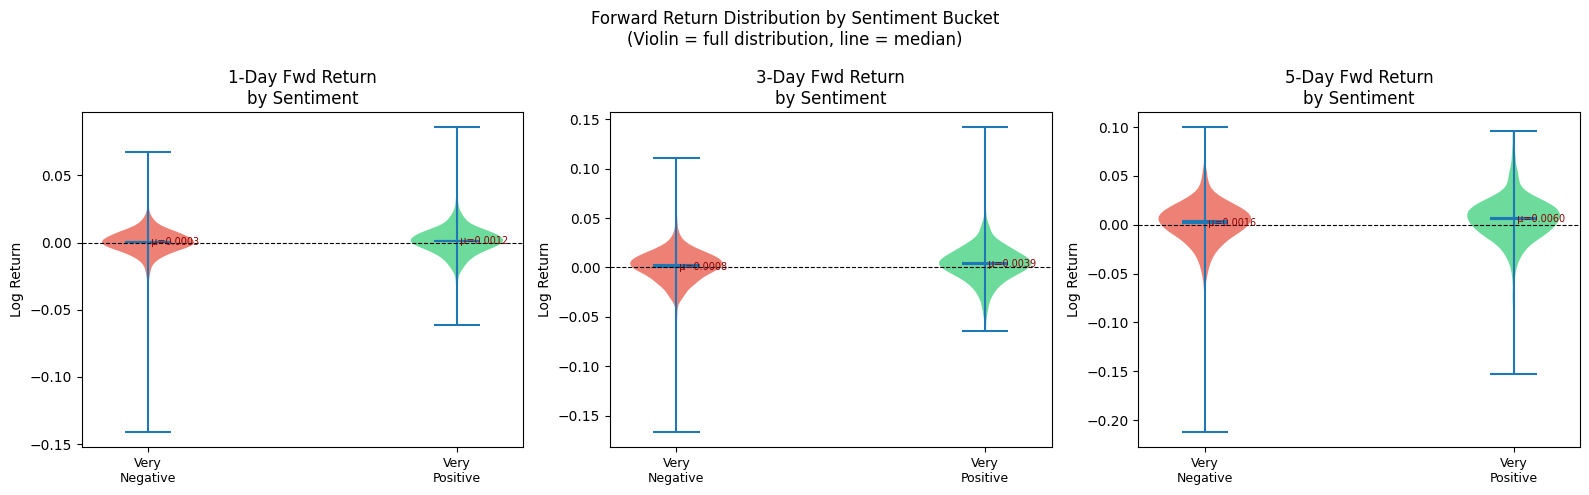


── Statistical Tests (Very Negative vs Very Positive) ──

1-Day Fwd:
  Neg mean : +0.00028   Pos mean : +0.00116
  T-test   : t=-1.486  p=0.1374  ❌
  Mann-Whitney: U=307640  p=0.1496  ❌

3-Day Fwd:
  Neg mean : +0.00077   Pos mean : +0.00386
  T-test   : t=-3.078  p=0.0021  ✅
  Mann-Whitney: U=295158  p=0.0068  ✅

5-Day Fwd:
  Neg mean : +0.00156   Pos mean : +0.00597
  T-test   : t=-3.413  p=0.0007  ✅
  Mann-Whitney: U=290327  p=0.0014  ✅


In [88]:
# ══════════════════════════════════════════════════════════════════════════════
#  ANALYSIS 1 — Magnitude: do negative days cause bigger moves?
# ══════════════════════════════════════════════════════════════════════════════
pos_days = merged[merged['sentiment_extreme'] == 'Very Positive']
neg_days = merged[merged['sentiment_extreme'] == 'Very Negative']
neu_days = merged[merged['sentiment_extreme'] == 'Neutral']

horizons = ['fwd_ret_1d', 'fwd_ret_3d', 'fwd_ret_5d']
labels   = ['1-Day Fwd', '3-Day Fwd', '5-Day Fwd']

# ── Debug: print group sizes upfront ─────────────────────────────────────────
print("── Group sizes ──")
for col in horizons:
    n, neu, p = neg_days[col].dropna(), neu_days[col].dropna(), pos_days[col].dropna()
    print(f"  {col}: VeryNeg={len(n)}  Neutral={len(neu)}  VeryPos={len(p)}")

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for ax, col, lbl in zip(axes, horizons, labels):
    data_neg = neg_days[col].dropna()
    data_neu = neu_days[col].dropna()
    data_pos = pos_days[col].dropna()

    # Build only valid groups (need >= 2 points for KDE)
    all_groups = [
        (data_neg, 'Very\nNegative', 0),
        (data_neu, 'Neutral',        1),
        (data_pos, 'Very\nPositive', 2),
    ]
    valid = [(g, l, p) for g, l, p in all_groups if len(g) >= 2]

    if len(valid) < 2:
        ax.set_title(f'{lbl}\n(insufficient data)')
        ax.text(0.5, 0.5, 'Not enough data', ha='center', va='center',
                transform=ax.transAxes, fontsize=10, color='gray')
        continue

    vdata  = [g for g, l, p in valid]
    vlbls  = [l for g, l, p in valid]
    vpos   = [p for g, l, p in valid]

    parts = ax.violinplot(vdata, positions=vpos, widths=0.6,
                          showmedians=True, showmeans=True)

    # Color violins by sentiment
    colors = {'Very\nNegative': '#e74c3c', 'Neutral': '#95a5a6', 'Very\nPositive': '#2ecc71'}
    for pc, (_, l, _) in zip(parts['bodies'], valid):
        pc.set_facecolor(colors.get(l, '#3498db'))
        pc.set_alpha(0.7)

    ax.set_xticks(vpos)
    ax.set_xticklabels(vlbls, fontsize=9)
    ax.axhline(0, color='black', linewidth=0.8, linestyle='--')
    ax.set_ylabel('Log Return')
    ax.set_title(f'{lbl} Return\nby Sentiment')

    # Annotate means
    for g, l, p in valid:
        if len(g) > 0:
            ax.text(p, g.mean(), f' μ={g.mean():.4f}',
                    va='center', fontsize=7, color='darkred')

plt.suptitle('Forward Return Distribution by Sentiment Bucket\n(Violin = full distribution, line = median)',
             fontsize=12)
plt.tight_layout()
plt.savefig('sentiment_return_violins.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Statistical tests ─────────────────────────────────────────────────────────
print("\n── Statistical Tests (Very Negative vs Very Positive) ──")
for col, lbl in zip(horizons, labels):
    d_neg = neg_days[col].dropna()
    d_pos = pos_days[col].dropna()

    if len(d_neg) < 2 or len(d_pos) < 2:
        print(f"\n{lbl}: ⚠️  Skipped — not enough data (neg={len(d_neg)}, pos={len(d_pos)})")
        continue

    t,    p    = stats.ttest_ind(d_neg, d_pos)
    mw_u, mw_p = stats.mannwhitneyu(d_neg, d_pos, alternative='two-sided')

    print(f"\n{lbl}:")
    print(f"  Neg mean : {d_neg.mean():+.5f}   Pos mean : {d_pos.mean():+.5f}")
    print(f"  T-test   : t={t:.3f}  p={p:.4f}  {'✅' if p<0.05 else '❌'}")
    print(f"  Mann-Whitney: U={mw_u:.0f}  p={mw_p:.4f}  {'✅' if mw_p<0.05 else '❌'}")

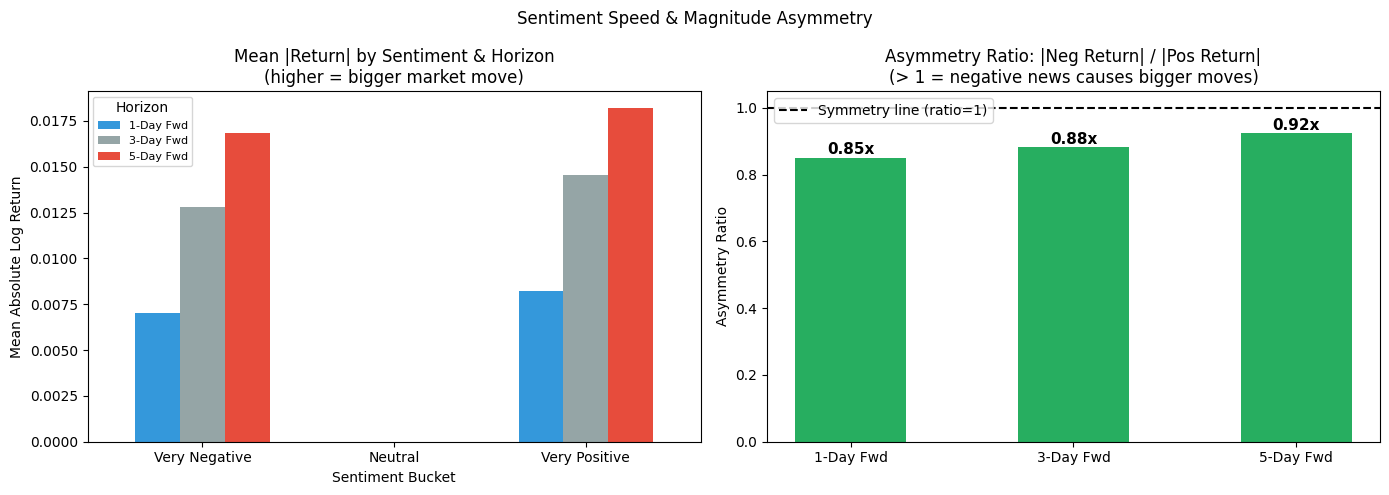


Asymmetry ratios (Neg/Pos magnitude):
  1-Day Fwd: 0.851x  → positive news moves market MORE
  3-Day Fwd: 0.882x  → positive news moves market MORE
  5-Day Fwd: 0.925x  → positive news moves market MORE


In [89]:
# ══════════════════════════════════════════════════════════════════════════════
#  ANALYSIS 2 — Speed: do markets react faster to bad news?
# ══════════════════════════════════════════════════════════════════════════════

# Compare abs(return) magnitude at each horizon
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ── Left: mean absolute return by sentiment × horizon ────────────────────────
horizon_data = {}
for label, group in [('Very Negative', neg_days), ('Neutral', neu_days), ('Very Positive', pos_days)]:
    horizon_data[label] = {
        lbl: group[col].abs().mean()
        for col, lbl in zip(horizons, labels)
    }

spd_df = pd.DataFrame(horizon_data).T
spd_df.plot(kind='bar', ax=axes[0],
            color=['#3498db', '#95a5a6', '#e74c3c'],
            width=0.7, rot=0)
axes[0].set_title('Mean |Return| by Sentiment & Horizon\n(higher = bigger market move)')
axes[0].set_ylabel('Mean Absolute Log Return')
axes[0].set_xlabel('Sentiment Bucket')
axes[0].legend(title='Horizon', fontsize=8)

# ── Right: asymmetry ratio — how negative reacts vs positive ─────────────────
asymmetry_ratios = {}
for col, lbl in zip(horizons, labels):
    neg_abs = neg_days[col].abs().mean()
    pos_abs = pos_days[col].abs().mean()
    # >1 means negative news causes bigger moves
    asymmetry_ratios[lbl] = neg_abs / (pos_abs + 1e-8)

colors_asym = ['#c0392b' if v > 1 else '#27ae60' for v in asymmetry_ratios.values()]
bars = axes[1].bar(asymmetry_ratios.keys(), asymmetry_ratios.values(),
                   color=colors_asym, width=0.5)
axes[1].axhline(1.0, color='black', linewidth=1.5, linestyle='--',
                label='Symmetry line (ratio=1)')
for bar, val in zip(bars, asymmetry_ratios.values()):
    axes[1].text(bar.get_x() + bar.get_width()/2, val + 0.01,
                 f'{val:.2f}x', ha='center', fontsize=11, fontweight='bold')
axes[1].set_title('Asymmetry Ratio: |Neg Return| / |Pos Return|\n(> 1 = negative news causes bigger moves)')
axes[1].set_ylabel('Asymmetry Ratio')
axes[1].legend()

plt.suptitle('Sentiment Speed & Magnitude Asymmetry', fontsize=12)
plt.tight_layout()
plt.savefig('sentiment_asymmetry.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nAsymmetry ratios (Neg/Pos magnitude):")
for lbl, ratio in asymmetry_ratios.items():
    direction = "negative news moves market MORE" if ratio > 1 else "positive news moves market MORE"
    print(f"  {lbl}: {ratio:.3f}x  → {direction}")

In [91]:
# ══════════════════════════════════════════════════════════════════════════════
#  ANALYSIS 4 — Granger Causality Test
#  "Does knowing yesterday's sentiment help predict today's return?"
#  This is a STATISTICAL test, not just correlation.
# ══════════════════════════════════════════════════════════════════════════════
from statsmodels.tsa.stattools import grangercausalitytests

print("="*55)
print("  GRANGER CAUSALITY TEST")
print("  H0: sentiment does NOT Granger-cause returns")
print("  Reject H0 (p < 0.05) → sentiment has predictive power")
print("="*55)

# Prepare bivariate series: [return, sentiment]
gc_data = merged[['fwd_ret_1d', 'compound']].dropna()

# Test lags 1 through 5
max_lags = 5
print(f"\nTest: Does compound sentiment → 1-day forward return?")
print(f"(using {len(gc_data)} observations)\n")

results = grangercausalitytests(gc_data[['fwd_ret_1d', 'compound']],
                                 maxlag=max_lags, verbose=False)

print(f"{'Lag':>4}  {'F-stat':>10}  {'p-value':>10}  {'Result':>15}")
print("-" * 45)
for lag in range(1, max_lags + 1):
    f_stat = results[lag][0]['ssr_ftest'][0]
    p_val  = results[lag][0]['ssr_ftest'][1]
    result = '✅ Reject H0' if p_val < 0.05 else '❌ Fail to reject'
    print(f"{lag:>4}  {f_stat:>10.4f}  {p_val:>10.4f}  {result:>15}")

print("\n(Also test reverse: do returns Granger-cause sentiment?)")
results_rev = grangercausalitytests(gc_data[['compound', 'fwd_ret_1d']],
                                     maxlag=max_lags, verbose=False)
print(f"{'Lag':>4}  {'F-stat':>10}  {'p-value':>10}  {'Result':>15}")
print("-" * 45)
for lag in range(1, max_lags + 1):
    f_stat = results_rev[lag][0]['ssr_ftest'][0]
    p_val  = results_rev[lag][0]['ssr_ftest'][1]
    result = '✅ Reject H0' if p_val < 0.05 else '❌ Fail to reject'
    print(f"{lag:>4}  {f_stat:>10.4f}  {p_val:>10.4f}  {result:>15}")

  GRANGER CAUSALITY TEST
  H0: sentiment does NOT Granger-cause returns
  Reject H0 (p < 0.05) → sentiment has predictive power

Test: Does compound sentiment → 1-day forward return?
(using 1814 observations)

 Lag      F-stat     p-value           Result
---------------------------------------------
   1      0.1269      0.7217  ❌ Fail to reject
   2      0.4893      0.6131  ❌ Fail to reject
   3      0.3361      0.7992  ❌ Fail to reject
   4      0.7344      0.5685  ❌ Fail to reject
   5      0.7794      0.5645  ❌ Fail to reject

(Also test reverse: do returns Granger-cause sentiment?)
 Lag      F-stat     p-value           Result
---------------------------------------------
   1      1.2078      0.2719  ❌ Fail to reject
   2      1.4439      0.2363  ❌ Fail to reject
   3      1.2307      0.2970  ❌ Fail to reject
   4      1.1327      0.3393  ❌ Fail to reject
   5      0.9655      0.4376  ❌ Fail to reject


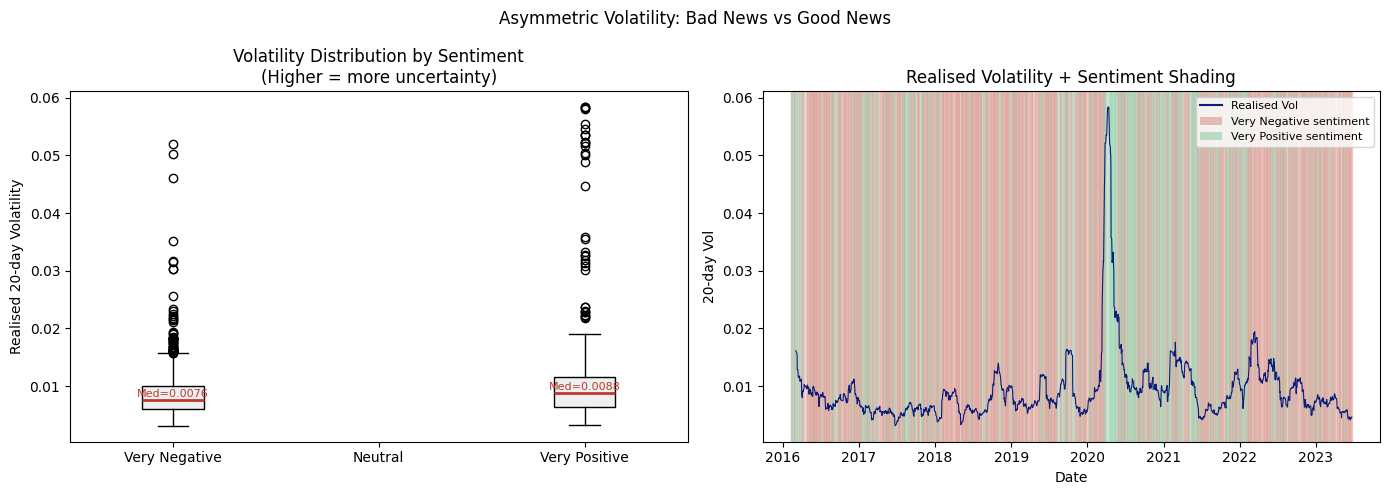


Volatility t-test (Neg vs Pos):
  Neg median vol : 0.00765
  Pos median vol : 0.00882
  t=-8.287  p=0.0000  ✅ Significant


In [92]:
# ══════════════════════════════════════════════════════════════════════════════
#  ANALYSIS 5 — Asymmetric Volatility
#  Does bad news raise volatility more than good news lowers it?
#  (The "leverage effect" — well-documented in equity markets)
# ══════════════════════════════════════════════════════════════════════════════

# Rolling 20-day realised volatility
merged['realised_vol'] = merged['LogReturn'].rolling(20).std()

# Separate vol by sentiment
pos_vol = merged[merged['sentiment_extreme'] == 'Very Positive']['realised_vol'].dropna()
neg_vol = merged[merged['sentiment_extreme'] == 'Very Negative']['realised_vol'].dropna()
neu_vol = merged[merged['sentiment_extreme'] == 'Neutral']['realised_vol'].dropna()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ── Left: vol distribution by sentiment ──────────────────────────────────────
axes[0].boxplot([neg_vol, neu_vol, pos_vol],
                labels=['Very Negative', 'Neutral', 'Very Positive'],
                patch_artist=True,
                boxprops=dict(facecolor='#ecf0f1'),
                medianprops=dict(color='#c0392b', linewidth=2))
axes[0].set_ylabel('Realised 20-day Volatility')
axes[0].set_title('Volatility Distribution by Sentiment\n(Higher = more uncertainty)')
for i, (grp, lbl) in enumerate([(neg_vol, 'neg'), (neu_vol, 'neu'), (pos_vol, 'pos')]):
    axes[0].text(i + 1, grp.median() + 0.0005,
                 f'Med={grp.median():.4f}', ha='center', fontsize=8, color='#c0392b')

# ── Right: vol over time, shaded by sentiment ─────────────────────────────────
ax_vol = axes[1]
ax_vol.plot(merged['Date'], merged['realised_vol'],
            color='#0b1d78', linewidth=0.8, label='20d Vol')

# Shade negative sentiment periods
neg_mask = merged['sentiment_extreme'] == 'Very Negative'
for _, row in merged[neg_mask].iterrows():
    ax_vol.axvspan(row['Date'], row['Date'] + pd.Timedelta(days=1),
                   alpha=0.08, color='#c0392b')

pos_mask = merged['sentiment_extreme'] == 'Very Positive'
for _, row in merged[pos_mask].iterrows():
    ax_vol.axvspan(row['Date'], row['Date'] + pd.Timedelta(days=1),
                   alpha=0.08, color='#27ae60')

# Legend patches
from matplotlib.patches import Patch
legend_elements = [
    plt.Line2D([0],[0], color='#0b1d78', lw=1.5, label='Realised Vol'),
    Patch(facecolor='#c0392b', alpha=0.3, label='Very Negative sentiment'),
    Patch(facecolor='#27ae60', alpha=0.3, label='Very Positive sentiment'),
]
ax_vol.legend(handles=legend_elements, fontsize=8)
ax_vol.set_title('Realised Volatility + Sentiment Shading')
ax_vol.set_xlabel('Date'); ax_vol.set_ylabel('20-day Vol')

plt.suptitle('Asymmetric Volatility: Bad News vs Good News', fontsize=12)
plt.tight_layout()
plt.savefig('asymmetric_volatility.png', dpi=150, bbox_inches='tight')
plt.show()

t, p = stats.ttest_ind(neg_vol, pos_vol)
print(f"\nVolatility t-test (Neg vs Pos):")
print(f"  Neg median vol : {neg_vol.median():.5f}")
print(f"  Pos median vol : {pos_vol.median():.5f}")
print(f"  t={t:.3f}  p={p:.4f}  {'✅ Significant' if p<0.05 else '❌ Not significant'}") 